# Three teacher with aug

In [19]:
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HUMAN_IMG_PATH  = "/kaggle/input/human-reticulocyte/SubsetAlldata"
SAVE_ROOT = Path("outputs") / "kd_augmented"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# training schedule
EPOCHS_TEACHER = 5
EPOCHS_STUDENT = 8
BATCH_SIZE = 32
LR = 1e-4
WEIGHT_DECAY = 1e-4
ALPHA, TEMPERATURE = 0.5, 4.0
GRAD_CLIP_NORM = 2.0
VAL_FRAC, TEST_FRAC = 0.2, 0.2
NUM_WORKERS = 2
IMG_SIZE = 224

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet  = [0.229, 0.224, 0.225]

# RIGOROUS augmentation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

# Build datasets
human_base  = datasets.ImageFolder(HUMAN_IMG_PATH, transform=None)
NUM_CLASSES = len(human_base.classes)

def stratified_split_indices_by_frac(base_ds, val_frac, test_frac=0.0, seed=SEED):
    rng = np.random.default_rng(seed)
    targets = np.array([y for _, y in base_ds.samples])
    idx = np.arange(len(targets))
    train_idx, val_idx, test_idx = [], [], []
    for c in np.unique(targets):
        ci = idx[targets==c].copy(); rng.shuffle(ci)
        n = len(ci)
        n_val  = max(1, int(round(n*val_frac)))
        n_test = max(0, int(round(n*test_frac)))
        n_val = min(n_val, n-1) if n>1 else 1
        val_idx.extend(ci[:n_val])
        test_idx.extend(ci[n_val:n_val+n_test])
        train_idx.extend(ci[n_val+n_test:])
    return train_idx, val_idx, test_idx

h_tr_idx, h_va_idx, h_te_idx = stratified_split_indices_by_frac(human_base, VAL_FRAC, TEST_FRAC)
human_train = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=train_tf), h_tr_idx)
human_val   = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf),  h_va_idx)
human_test  = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf),  h_te_idx)

print("Human dataset sizes after augmentation:")
print(" Train:", len(human_train), " Val:", len(human_val), " Test:", len(human_test), " Classes:", human_base.classes)

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True)

human_train_loader = make_loader(human_train, shuffle=True)
human_val_loader   = make_loader(human_val,   shuffle=False)
human_test_loader  = make_loader(human_test,  shuffle=False)

# ====================== UTILS ======================
def replace_classifier_for_num_classes(model, num_classes):
    if isinstance(model, models.SqueezeNet):
        model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1))
        model.num_classes = num_classes
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_features = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear):
                in_features = layer.in_features; break
        model.classifier[-1] = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'fc'):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    else:
        raise ValueError("Unsupported model type.")
    return model

def count_params_m(model): return sum(p.numel() for p in model.parameters()) / 1e6
def save_state(model, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)
    return path.stat().st_size / (1024*1024)

def optim_for(params, lr): return torch.optim.Adam(params, lr=lr, weight_decay=WEIGHT_DECAY)

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x); loss = loss_fn(out, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
        total += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    dur = time.time()-start
    return total/max(n,1), correct/max(n,1), dur

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval()
    y_true, y_pred = [], []
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())
    acc = accuracy_score(y_true, y_pred)*100.0
    f1m = f1_score(y_true, y_pred, average="macro")*100.0
    if return_preds: return acc, f1m, y_true, y_pred
    return acc, f1m

# ✅ NEW: per-class accuracy helper
def class_wise_accuracy(y_true, y_pred, class_names):
    accs = {}
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    for i, cls in enumerate(class_names):
        mask = (y_true == i)
        accs[cls] = (y_pred[mask] == y_true[mask]).mean() * 100 if mask.sum() > 0 else 0.0
    return accs

class EarlyStopper:
    def __init__(self, patience=5):
        self.patience, self.best, self.count = patience, -float("inf"), 0
    def step(self, metric):
        if metric > self.best:
            self.best, self.count = metric, 0; return True
        else: self.count += 1; return False
    def should_stop(self): return self.count >= self.patience

# ====================== History Recorder ======================
history = {}
def record_history(name, epoch, tr_loss, tr_acc, v_loss, v_acc, dur):
    if name not in history:
        history[name] = {"epoch": [], "train_loss": [], "train_acc": [],
                         "val_loss": [], "val_acc": [], "time": []}
    history[name]["epoch"].append(epoch)
    history[name]["train_loss"].append(tr_loss)
    history[name]["train_acc"].append(tr_acc*100)
    history[name]["val_loss"].append(v_loss)
    history[name]["val_acc"].append(v_acc)
    history[name]["time"].append(dur)

# ====================== Teacher Training ======================
def train_teacher(name, model_fn):
    model = model_fn(weights="DEFAULT")
    model = replace_classifier_for_num_classes(model, NUM_CLASSES).to(DEVICE)
    ce = nn.CrossEntropyLoss(label_smoothing=0.05)
    opt = optim_for(model.parameters(), LR)
    es = EarlyStopper(5)
    best_path = SAVE_ROOT / f"{name}_best.pth"

    for ep in range(1, EPOCHS_TEACHER+1):
        tr_loss, tr_acc, dur = run_epoch(model, human_train_loader, ce, opt)
        v_acc, v_f1 = eval_metrics(model, human_val_loader)
        record_history(name, ep, tr_loss, tr_acc, 0, v_acc, dur)
        print(f"[{name}] Ep{ep}: loss={tr_loss:.4f} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if es.step(v_acc): save_state(model, best_path)
        if es.should_stop(): break

    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    return model

teachers_cfg = [
    ("mobilenet_v2",    models.mobilenet_v2),
    ("efficientnet_b0", models.efficientnet_b0),
    ("squeezenet1_1",   models.squeezenet1_1),
]

teachers = {}
for name, fn in teachers_cfg:
    teachers[name] = train_teacher(name, fn)

# ====================== KD Student ======================
class StudentNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.shufflenet_v2_x0_5(weights="DEFAULT")
        in_f = base.fc.in_features
        base.fc = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(in_f, num_classes))
        self.model = base
    def forward(self, x): return self.model(x)

student = StudentNet(NUM_CLASSES).to(DEVICE)
opt_s = torch.optim.Adam(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
ce_s  = nn.CrossEntropyLoss(label_smoothing=0.05)
kl = nn.KLDivLoss(reduction="batchmean")
t_models = [m.to(DEVICE).eval() for m in teachers.values()]

def kd_epoch(student, loader):
    student.train()
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad():
            ps = [F.softmax(m(imgs)/TEMPERATURE, dim=1) for m in t_models]
            t_soft = sum(ps)/len(ps)
        logits = student(imgs)
        loss = ALPHA*ce_s(logits, labels) + (1-ALPHA)*kl(
            F.log_softmax(logits/TEMPERATURE, dim=1), t_soft
        )
        opt_s.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), GRAD_CLIP_NORM)
        opt_s.step()
        total += loss.item()*imgs.size(0)
        correct += (logits.argmax(1)==labels).sum().item(); n += imgs.size(0)
    dur = time.time()-start
    return total/max(n,1), correct/max(n,1), dur

best_path = SAVE_ROOT / "student_best.pth"
es_stud = EarlyStopper(5)

for ep in range(1, EPOCHS_STUDENT+1):
    tr_loss, tr_acc, dur = kd_epoch(student, human_train_loader)
    v_acc, v_f1 = eval_metrics(student, human_val_loader)
    record_history("student", ep, tr_loss, tr_acc, 0, v_acc, dur)
    print(f"[Student KD] Ep{ep}: loss={tr_loss:.4f} val_acc={v_acc:.2f} f1={v_f1:.2f}")
    if es_stud.step(v_acc): save_state(student, best_path)
    if es_stud.should_stop(): break
student.load_state_dict(torch.load(best_path, map_location=DEVICE))

# ====================== Final Reports ======================
def final_reports(name, model, loader):
    acc, f1, y_true, y_pred = eval_metrics(model, loader, return_preds=True)
    print(f"\n[{name}] Classification Report:\n",
          classification_report(y_true, y_pred, target_names=human_base.classes))
    
    # ✅ Per-class accuracy
    per_class_acc = class_wise_accuracy(y_true, y_pred, human_base.classes)
    print(f"[{name}] Per-class Accuracy:")
    for cls, acc_c in per_class_acc.items():
        print(f"  {cls}: {acc_c:.2f}%")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=human_base.classes,
                yticklabels=human_base.classes)
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix ({name})")
    plt.tight_layout()
    plt.savefig(SAVE_ROOT / f"{name}_confusion_matrix.png"); plt.close()
    size_mb = save_state(model, SAVE_ROOT / f"{name}_temp.pth")
    params_m = count_params_m(model)
    avg_time = np.mean(history.get(name, {}).get("time", [0]))
    return {"acc": acc, "f1": f1, "size": size_mb, "params": params_m, "time": avg_time, "per_class": per_class_acc}

all_reports = {}
for name, model in teachers.items():
    all_reports[name] = final_reports(name, model, human_test_loader)
all_reports["student"] = final_reports("student", student, human_test_loader)

print("\n=== MODEL SUMMARY ===")
for name, rep in all_reports.items():
    print(f"{name}: Acc={rep['acc']:.2f}, F1={rep['f1']:.2f}, "
          f"Size={rep['size']:.2f}MB, Params={rep['params']:.2f}M, "
          f"AvgTime/ep={rep['time']:.2f}s")
    for cls, acc_c in rep["per_class"].items():
        print(f"   - {cls}: {acc_c:.2f}%")

# Loss/Acc plots
for name, logs in history.items():
    plt.figure(figsize=(8,4))
    plt.plot(logs["epoch"], logs["train_loss"], label="Train Loss")
    plt.plot(logs["epoch"], logs["val_loss"], label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{name} Loss"); plt.legend()
    plt.tight_layout(); plt.savefig(SAVE_ROOT / f"{name}_loss_curve.png"); plt.close()

    plt.figure(figsize=(8,4))
    plt.plot(logs["epoch"], logs["train_acc"], label="Train Acc")
    plt.plot(logs["epoch"], logs["val_acc"], label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)"); plt.title(f"{name} Accuracy"); plt.legend()
    plt.tight_layout(); plt.savefig(SAVE_ROOT / f"{name}_acc_curve.png"); plt.close()


Human dataset sizes after augmentation:
 Train: 872  Val: 291  Test: 291  Classes: ['BG', 'erythrocyte', 'reticulocyte']
[mobilenet_v2] Ep1: loss=0.9383 val_acc=85.22 f1=85.44
[mobilenet_v2] Ep2: loss=0.5856 val_acc=86.94 f1=87.10
[mobilenet_v2] Ep3: loss=0.3939 val_acc=93.81 f1=93.86
[mobilenet_v2] Ep4: loss=0.3049 val_acc=93.81 f1=93.86
[mobilenet_v2] Ep5: loss=0.2624 val_acc=93.13 f1=93.16
[efficientnet_b0] Ep1: loss=0.8623 val_acc=86.25 f1=86.38
[efficientnet_b0] Ep2: loss=0.4494 val_acc=94.50 f1=94.51
[efficientnet_b0] Ep3: loss=0.3047 val_acc=96.91 f1=96.90
[efficientnet_b0] Ep4: loss=0.2612 val_acc=95.88 f1=95.86
[efficientnet_b0] Ep5: loss=0.2262 val_acc=95.53 f1=95.55


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth
100%|██████████| 4.73M/4.73M [00:00<00:00, 63.3MB/s]


[squeezenet1_1] Ep1: loss=0.7161 val_acc=88.32 f1=88.46
[squeezenet1_1] Ep2: loss=0.4208 val_acc=93.13 f1=93.20
[squeezenet1_1] Ep3: loss=0.3655 val_acc=97.94 f1=97.95
[squeezenet1_1] Ep4: loss=0.3290 val_acc=95.53 f1=95.56


Downloading: "https://download.pytorch.org/models/shufflenetv2_x0.5-f707e7126e.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x0.5-f707e7126e.pth


[squeezenet1_1] Ep5: loss=0.2744 val_acc=95.88 f1=95.87


100%|██████████| 5.28M/5.28M [00:00<00:00, 67.9MB/s]


[Student KD] Ep1: loss=0.5982 val_acc=62.20 f1=53.48
[Student KD] Ep2: loss=0.5793 val_acc=79.04 f1=78.15
[Student KD] Ep3: loss=0.5488 val_acc=81.10 f1=80.95
[Student KD] Ep4: loss=0.5048 val_acc=82.13 f1=82.24
[Student KD] Ep5: loss=0.4604 val_acc=85.91 f1=86.10
[Student KD] Ep6: loss=0.4135 val_acc=87.97 f1=88.13
[Student KD] Ep7: loss=0.3605 val_acc=89.35 f1=89.54
[Student KD] Ep8: loss=0.3185 val_acc=90.38 f1=90.56

[mobilenet_v2] Classification Report:
               precision    recall  f1-score   support

          BG       1.00      0.95      0.97        96
 erythrocyte       0.97      0.92      0.94       100
reticulocyte       0.89      0.98      0.93        95

    accuracy                           0.95       291
   macro avg       0.95      0.95      0.95       291
weighted avg       0.95      0.95      0.95       291

[mobilenet_v2] Per-class Accuracy:
  BG: 94.79%
  erythrocyte: 92.00%
  reticulocyte: 97.89%

[efficientnet_b0] Classification Report:
               preci

In [2]:
import os
import hashlib
from collections import defaultdict

DATASET_PATH = "/kaggle/input/human-reticulocyte/SubsetAlldata"

# Function to compute md5 hash of an image
def get_file_hash(filepath):
    with open(filepath, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# Dictionary to track hashes
hash_dict = defaultdict(list)

# Walk through all class folders
for root, dirs, files in os.walk(DATASET_PATH):
    for fname in files:
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            fpath = os.path.join(root, fname)
            file_hash = get_file_hash(fpath)
            hash_dict[file_hash].append(fpath)

# Collect duplicates
duplicates = {h: paths for h, paths in hash_dict.items() if len(paths) > 1}

# Print results
if duplicates:
    print("⚠️ Found duplicate images:")
    for h, paths in duplicates.items():
        print("\nHash:", h)
        for p in paths:
            print("   ", p)
else:
    print("✅ No duplicate images found!")


✅ No duplicate images found!


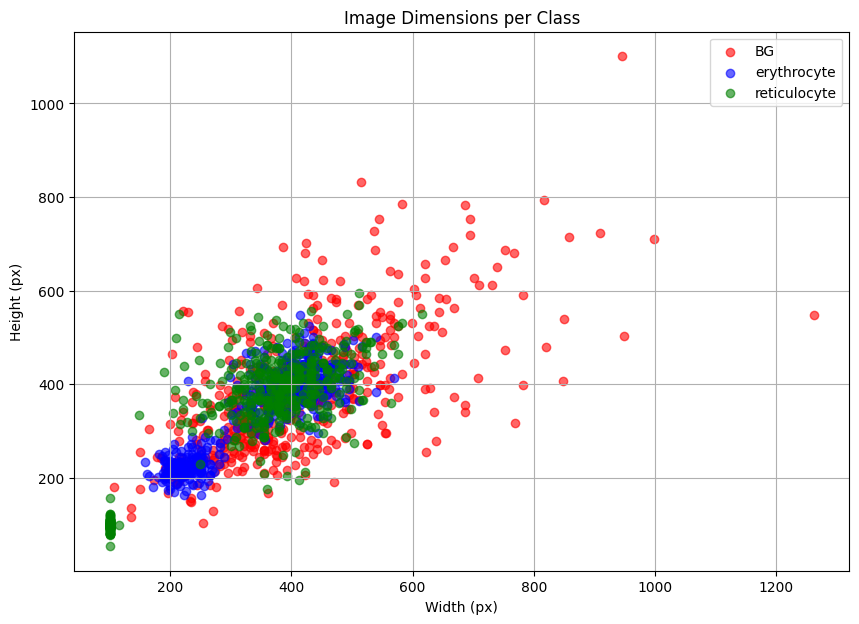

In [5]:
import os
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = "/kaggle/input/human-reticulocyte/SubsetAlldata"

# Collect image dimensions per class
dims = {"BG": [], "erythrocyte": [], "reticulocyte": []}

for cls in dims.keys():
    folder = os.path.join(DATASET_PATH, cls)
    for fname in os.listdir(folder):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            fpath = os.path.join(folder, fname)
            try:
                with Image.open(fpath) as img:
                    w, h = img.size
                    dims[cls].append((w, h))
            except Exception as e:
                print("Error loading:", fpath, e)

# Scatter plot for each class
plt.figure(figsize=(10, 7))
colors = {"BG": "red", "erythrocyte": "blue", "reticulocyte": "green"}

for cls, points in dims.items():
    if points:  # skip if no images
        xs, ys = zip(*points)
        plt.scatter(xs, ys, label=cls, alpha=0.6, c=colors[cls])

plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Human Reticulocyte image Dimensions per Class")
plt.legend()
plt.grid(True)
plt.show()


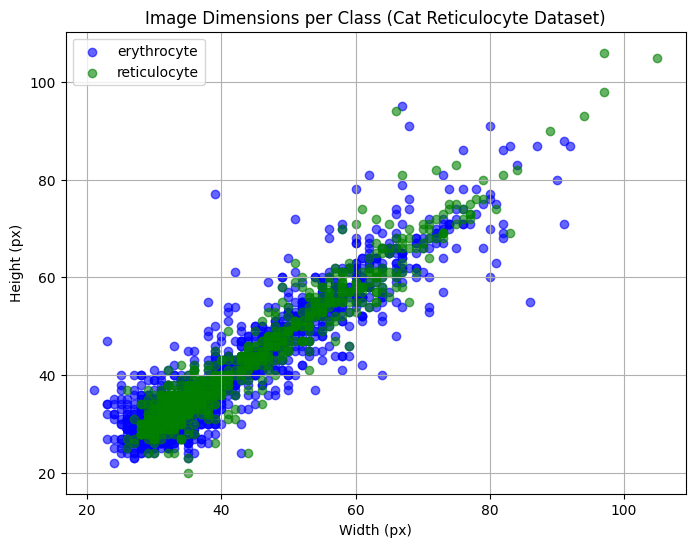

In [10]:
import os
from PIL import Image
import matplotlib.pyplot as plt

DATASET_PATH = "/kaggle/input/cat-reticulocyte/felineAlldata"

# Collect image dimensions per class (only erythrocyte & reticulocyte here)
dims_cat = {"erythrocyte": [], "reticulocyte": []}

for cls in dims_cat.keys():
    folder = os.path.join(DATASET_PATH, cls)
    for fname in os.listdir(folder):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            fpath = os.path.join(folder, fname)
            try:
                with Image.open(fpath) as img:
                    w, h = img.size
                    dims_cat[cls].append((w, h))
            except Exception as e:
                print("Error loading:", fpath, e)

# Scatter plot
plt.figure(figsize=(8, 6))
colors = {"erythrocyte": "blue", "reticulocyte": "green"}

for cls, points in dims_cat.items():
    if points:
        xs, ys = zip(*points)
        plt.scatter(xs, ys, label=cls, alpha=0.6, c=colors[cls])

plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.title("Image Dimensions per Class (Cat Reticulocyte Dataset)")
plt.legend()
plt.grid(True)
plt.show()


In [3]:
# ====================== ENSEMBLED MODEL ======================
@torch.no_grad()
def ensemble_eval(models, loader):
    all_preds, all_true = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        probs = []
        for m in models:
            m.eval()
            logits = m(x)
            probs.append(F.softmax(logits, dim=1).cpu().numpy())
        avg_probs = np.mean(probs, axis=0)
        preds = np.argmax(avg_probs, axis=1)
        all_preds.extend(preds.tolist())
        all_true.extend(y.numpy().tolist())
    return all_true, all_preds

# combine teachers + student
all_models = list(teachers.values()) + [student]
y_true, y_pred = ensemble_eval(all_models, human_test_loader)

# Overall report
print("\n[ENSEMBLED] Classification Report:\n", 
      classification_report(y_true, y_pred, target_names=human_base.classes))

# ✅ Per-class accuracy
per_class_acc = class_wise_accuracy(y_true, y_pred, human_base.classes)
print("[ENSEMBLED] Per-class Accuracy:")
for cls, acc_c in per_class_acc.items():
    print(f"  {cls}: {acc_c:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=human_base.classes,
            yticklabels=human_base.classes)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix (Ensembled)")
plt.tight_layout()
plt.savefig(SAVE_ROOT / "ensemble_confusion_matrix.png")
plt.close()



[ENSEMBLED] Classification Report:
               precision    recall  f1-score   support

          BG       1.00      0.98      0.99        96
 erythrocyte       0.99      0.99      0.99       100
reticulocyte       0.98      1.00      0.99        95

    accuracy                           0.99       291
   macro avg       0.99      0.99      0.99       291
weighted avg       0.99      0.99      0.99       291

[ENSEMBLED] Per-class Accuracy:
  BG: 97.92%
  erythrocyte: 99.00%
  reticulocyte: 100.00%


# Threee teacher without aug

Human dataset sizes:
 Train: 872  Val: 291  Test: 291  Classes: ['BG', 'erythrocyte', 'reticulocyte']
[mobilenet_v2] Ep1: loss=0.8614 val_acc=95.53
[mobilenet_v2] Ep2: loss=0.3987 val_acc=98.63
[mobilenet_v2] Ep3: loss=0.2326 val_acc=98.63
[mobilenet_v2] Ep4: loss=0.2050 val_acc=98.97
[mobilenet_v2] Ep5: loss=0.2021 val_acc=98.63
[efficientnet_b0] Ep1: loss=0.7500 val_acc=87.97
[efficientnet_b0] Ep2: loss=0.2752 val_acc=98.63
[efficientnet_b0] Ep3: loss=0.2148 val_acc=98.97
[efficientnet_b0] Ep4: loss=0.2023 val_acc=98.97
[efficientnet_b0] Ep5: loss=0.1867 val_acc=98.97
[squeezenet1_1] Ep1: loss=0.5917 val_acc=93.47
[squeezenet1_1] Ep2: loss=0.2660 val_acc=98.63
[squeezenet1_1] Ep3: loss=0.2189 val_acc=98.97
[squeezenet1_1] Ep4: loss=0.1983 val_acc=98.28
[squeezenet1_1] Ep5: loss=0.1952 val_acc=98.97
[Student KD] Ep1: loss=0.6166 val_acc=75.26
[Student KD] Ep2: loss=0.5905 val_acc=91.07
[Student KD] Ep3: loss=0.5493 val_acc=92.10
[Student KD] Ep4: loss=0.4833 val_acc=93.13
[Student KD]

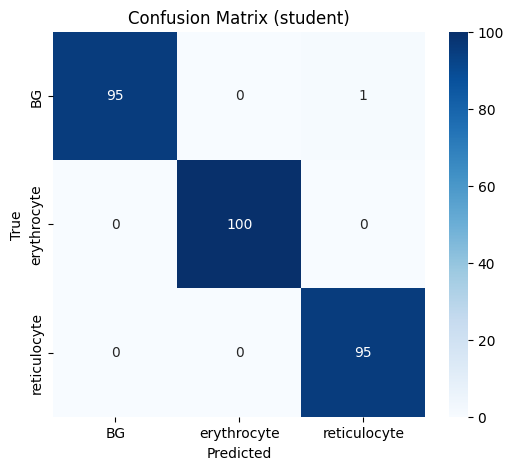

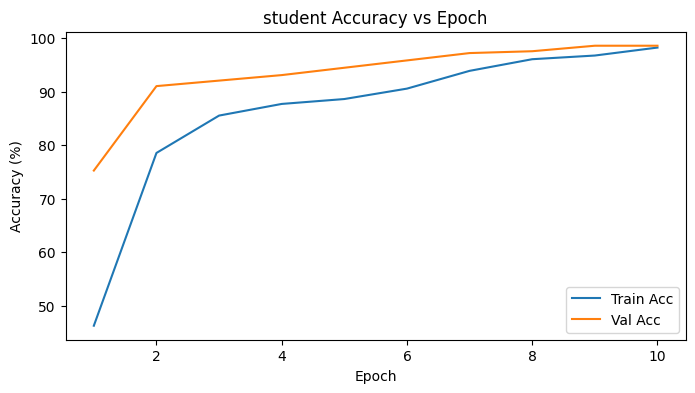


===== ENSEMBLE REPORT =====
Overall Acc=100.00%, F1=100.00%

Classification Report:
              precision    recall  f1-score   support

          BG      1.000     1.000     1.000        96
 erythrocyte      1.000     1.000     1.000       100
reticulocyte      1.000     1.000     1.000        95

    accuracy                          1.000       291
   macro avg      1.000     1.000     1.000       291
weighted avg      1.000     1.000     1.000       291

Per-class Accuracy:
  BG: 100.00%
  erythrocyte: 100.00%
  reticulocyte: 100.00%


In [17]:
# ====================== IMPORTS ======================
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HUMAN_IMG_PATH  = "/kaggle/input/human-reticulocyte/SubsetAlldata"
SAVE_ROOT = Path("outputs") / "kd_reports_inline"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# training schedule
EPOCHS_TEACHER = 5
EPOCHS_STUDENT = 10
BATCH_SIZE = 32
LR = 1e-4
WEIGHT_DECAY = 1e-4
ALPHA, TEMPERATURE = 0.5, 4.0
GRAD_CLIP_NORM = 2.0
VAL_FRAC, TEST_FRAC = 0.2, 0.2
NUM_WORKERS = 2
IMG_SIZE = 224

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

human_base  = datasets.ImageFolder(HUMAN_IMG_PATH, transform=None)
NUM_CLASSES = len(human_base.classes)

def stratified_split_indices_by_frac(base_ds, val_frac, test_frac=0.0, seed=SEED):
    rng = np.random.default_rng(seed)
    targets = np.array([y for _, y in base_ds.samples])
    idx = np.arange(len(targets))
    train_idx, val_idx, test_idx = [], [], []
    for c in np.unique(targets):
        ci = idx[targets==c].copy(); rng.shuffle(ci)
        n = len(ci)
        n_val  = max(1, int(round(n*val_frac)))
        n_test = max(0, int(round(n*test_frac)))
        n_val = min(n_val, n-1) if n>1 else 1
        val_idx.extend(ci[:n_val])
        test_idx.extend(ci[n_val:n_val+n_test])
        train_idx.extend(ci[n_val+n_test:])
    return train_idx, val_idx, test_idx

h_tr_idx, h_va_idx, h_te_idx = stratified_split_indices_by_frac(human_base, VAL_FRAC, TEST_FRAC)
human_train = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=train_tf), h_tr_idx)
human_val   = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf),  h_va_idx)
human_test  = Subset(datasets.ImageFolder(HUMAN_IMG_PATH, transform=eval_tf),  h_te_idx)

print("Human dataset sizes:")
print(" Train:", len(human_train), " Val:", len(human_val), " Test:", len(human_test), " Classes:", human_base.classes)

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True)

human_train_loader = make_loader(human_train, shuffle=True)
human_val_loader   = make_loader(human_val,   shuffle=False)
human_test_loader  = make_loader(human_test,  shuffle=False)

# ====================== UTILS ======================
def replace_classifier_for_num_classes(model, num_classes):
    if isinstance(model, models.SqueezeNet):
        model.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1))
        model.num_classes = num_classes
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_features = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear):
                in_features = layer.in_features; break
        model.classifier[-1] = nn.Linear(in_features, num_classes)
    elif hasattr(model, 'fc'):
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    else:
        raise ValueError("Unsupported model type.")
    return model

def optim_for(params, lr): return torch.optim.Adam(params, lr=lr, weight_decay=WEIGHT_DECAY)

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x); loss = loss_fn(out, y)
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
        total += loss.item()*x.size(0); correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return total/max(n,1), correct/max(n,1)

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval()
    y_true, y_pred = [], []
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())
    acc = accuracy_score(y_true, y_pred)*100.0
    f1m = f1_score(y_true, y_pred, average="macro")*100.0
    if return_preds: return acc, f1m, y_true, y_pred
    return acc, f1m

def class_wise_accuracy(y_true, y_pred, class_names):
    accs = {}
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    for i, cls in enumerate(class_names):
        mask = (y_true == i)
        accs[cls] = (y_pred[mask] == y_true[mask]).mean() * 100 if mask.sum() > 0 else 0.0
    return accs

# ====================== History Recorder ======================
history = {}
def record_history(name, epoch, tr_loss, tr_acc, v_loss, v_acc):
    if name not in history:
        history[name] = {"epoch": [], "train_loss": [], "train_acc": [],
                         "val_loss": [], "val_acc": []}
    history[name]["epoch"].append(epoch)
    history[name]["train_loss"].append(tr_loss)
    history[name]["train_acc"].append(tr_acc*100)
    history[name]["val_loss"].append(v_loss)
    history[name]["val_acc"].append(v_acc)

# ====================== Teacher Training ======================
def train_teacher(name, model_fn):
    model = model_fn(weights="DEFAULT")
    model = replace_classifier_for_num_classes(model, NUM_CLASSES).to(DEVICE)
    ce = nn.CrossEntropyLoss(label_smoothing=0.05)
    opt = optim_for(model.parameters(), LR)
    for ep in range(1, EPOCHS_TEACHER+1):
        tr_loss, tr_acc = run_epoch(model, human_train_loader, ce, opt)
        v_acc, v_f1 = eval_metrics(model, human_val_loader)
        record_history(name, ep, tr_loss, tr_acc, 0, v_acc)
        print(f"[{name}] Ep{ep}: loss={tr_loss:.4f} val_acc={v_acc:.2f}")
    return model

teachers_cfg = [
    ("mobilenet_v2",    models.mobilenet_v2),
    ("efficientnet_b0", models.efficientnet_b0),
    ("squeezenet1_1",   models.squeezenet1_1),
]
teachers = {name: train_teacher(name, fn) for name, fn in teachers_cfg}

# ====================== KD Student ======================
class StudentNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.shufflenet_v2_x0_5(weights="DEFAULT")
        in_f = base.fc.in_features
        base.fc = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(in_f, num_classes))
        self.model = base
    def forward(self, x): return self.model(x)

student = StudentNet(NUM_CLASSES).to(DEVICE)
opt_s = optim_for(student.parameters(), LR)
ce_s  = nn.CrossEntropyLoss(label_smoothing=0.05)
kl = nn.KLDivLoss(reduction="batchmean")
t_models = [m.to(DEVICE).eval() for m in teachers.values()]

def kd_epoch(student, loader):
    student.train()
    total, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.no_grad():
            ps = [F.softmax(m(imgs)/TEMPERATURE, dim=1) for m in t_models]
            t_soft = sum(ps)/len(ps)
        logits = student(imgs)
        loss = ALPHA*ce_s(logits, labels) + (1-ALPHA)*kl(
            F.log_softmax(logits/TEMPERATURE, dim=1), t_soft
        )
        opt_s.zero_grad(set_to_none=True); loss.backward(); opt_s.step()
        total += loss.item()*imgs.size(0)
        correct += (logits.argmax(1)==labels).sum().item(); n += imgs.size(0)
    return total/max(n,1), correct/max(n,1)

for ep in range(1, EPOCHS_STUDENT+1):
    tr_loss, tr_acc = kd_epoch(student, human_train_loader)
    v_acc, v_f1 = eval_metrics(student, human_val_loader)
    record_history("student", ep, tr_loss, tr_acc, 0, v_acc)
    print(f"[Student KD] Ep{ep}: loss={tr_loss:.4f} val_acc={v_acc:.2f}")

# ====================== REPORT FUNCTION ======================
def full_report(name, model, loader, logs=None, y_true=None, y_pred=None):
    if y_true is None or y_pred is None:
        acc, f1, y_true, y_pred = eval_metrics(model, loader, return_preds=True)
    else:
        acc, f1 = accuracy_score(y_true, y_pred)*100, f1_score(y_true, y_pred, average="macro")*100

    print(f"\n===== {name.upper()} REPORT =====")
    print(f"Overall Acc={acc:.2f}%, F1={f1:.2f}%")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=human_base.classes, digits=3))

    # Per-class Accuracy
    per_class_acc = class_wise_accuracy(y_true, y_pred, human_base.classes)
    print("Per-class Accuracy:")
    for cls, a in per_class_acc.items():
        print(f"  {cls}: {a:.2f}%")

    # Only for student: plot final CM and Acc vs Epochs
    if name.lower() == "student":
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=human_base.classes,
                    yticklabels=human_base.classes)
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.title(f"Confusion Matrix ({name})")
        plt.show()

        plt.figure(figsize=(8,4))
        plt.plot(logs["epoch"], logs["train_acc"], label="Train Acc")
        plt.plot(logs["epoch"], logs["val_acc"], label="Val Acc")
        plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
        plt.title(f"{name} Accuracy vs Epoch")
        plt.legend(); plt.show()

# ====================== ENSEMBLE EVAL ======================
@torch.no_grad()
def ensemble_eval(models, loader):
    all_preds, all_true = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        probs = []
        for m in models:
            m.eval()
            logits = m(x)
            probs.append(F.softmax(logits, dim=1).cpu().numpy())
        avg_probs = np.mean(probs, axis=0)
        preds = np.argmax(avg_probs, axis=1)
        all_preds.extend(preds.tolist())
        all_true.extend(y.numpy().tolist())
    return all_true, all_preds

# ====================== RUN REPORTS ======================
for name, model in teachers.items():
    full_report(name, model, human_test_loader)

full_report("student", student, human_test_loader, logs=history["student"])

y_true, y_pred = ensemble_eval(list(teachers.values()) + [student], human_test_loader)
full_report("ensemble", None, human_test_loader, y_true=y_true, y_pred=y_pred)



In [7]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ====================== GRAD-CAM CLASS ======================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hooks = []

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hooks.append(target_layer.register_forward_hook(forward_hook))
        self.hooks.append(target_layer.register_backward_hook(backward_hook))

    def remove_hooks(self):
        for h in self.hooks:
            h.remove()

    def __call__(self, x, class_idx=None):
        self.model.eval()
        out = self.model(x)
        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        score = out[:, class_idx]
        self.model.zero_grad()
        score.backward(retain_graph=True)

        # Global average pooling of gradients
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1).squeeze().cpu().numpy()

        # Normalize
        cam = np.maximum(cam, 0)
        cam = cam - cam.min()
        cam = cam / cam.max()
        cam = cv2.resize(cam, (x.shape[2], x.shape[3]))
        return cam

# ====================== BOUNDING BOXES ======================
def get_bounding_boxes(cam, threshold=0.4):
    mask = (cam > threshold).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = [cv2.boundingRect(cnt) for cnt in contours]
    return boxes

# ====================== VISUALIZATION ======================
def visualize_cam_on_image(img_tensor, cam, boxes=None):
    """
    img_tensor: (C,H,W) torch tensor
    cam: numpy heatmap (H,W)
    boxes: optional list of (x,y,w,h) bounding boxes
    """
    # Convert tensor to numpy image
    img = img_tensor.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())
    img = (img * 255).astype(np.uint8)

    # Create heatmap overlay
    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img, 0.5, heatmap, 0.5, 0)

    # Draw bounding boxes if provided
    if boxes is not None:
        for (x,y,w,h) in boxes:
            cv2.rectangle(overlay, (x,y), (x+w,y+h), (0,255,0), 2)

    # Show result
    plt.figure(figsize=(5,5))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

# ====================== HOW TO USE ======================
# Example after training student
"""
img, label = human_test[0]   # one test image
input_tensor = img.unsqueeze(0).to(DEVICE)

# Pick a deep conv layer for Grad-CAM (example for ShuffleNetV2)
target_layer = student.model.conv5[0]

# Run Grad-CAM
gradcam = GradCAM(student.model, target_layer)
cam = gradcam(input_tensor)

# Bounding boxes
boxes = get_bounding_boxes(cam, threshold=0.4)

# Visualize
visualize_cam_on_image(img, cam, boxes)
gradcam.remove_hooks()
"""


'\nimg, label = human_test[0]   # one test image\ninput_tensor = img.unsqueeze(0).to(DEVICE)\n\n# Pick a deep conv layer for Grad-CAM (example for ShuffleNetV2)\ntarget_layer = student.model.conv5[0]\n\n# Run Grad-CAM\ngradcam = GradCAM(student.model, target_layer)\ncam = gradcam(input_tensor)\n\n# Bounding boxes\nboxes = get_bounding_boxes(cam, threshold=0.4)\n\n# Visualize\nvisualize_cam_on_image(img, cam, boxes)\ngradcam.remove_hooks()\n'

Explaining Image: /kaggle/input/human-reticulocyte/SubsetAlldata/BG/4_C0180.jpg (True label: BG)


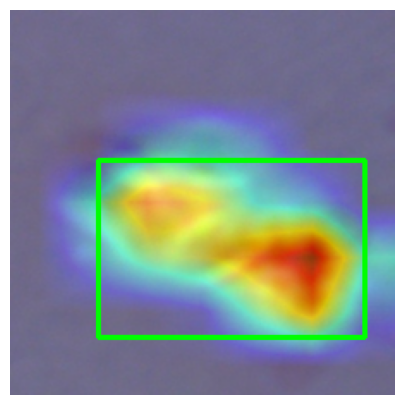

In [12]:
# Pick the image
img, label = human_test[0]
orig_idx = human_test.indices[0]
img_path, class_idx = human_base.samples[orig_idx]

print(f"Explaining Image: {img_path} (True label: {human_base.classes[class_idx]})")

# Prepare for Grad-CAM
input_tensor = img.unsqueeze(0).to(DEVICE)
target_layer = student.model.conv5[0]   # adjust for ShuffleNet
gradcam = GradCAM(student.model, target_layer)

# Heatmap + boxes
cam = gradcam(input_tensor)
boxes = get_bounding_boxes(cam, threshold=0.4)

# Visualize overlay
visualize_cam_on_image(img, cam, boxes)
gradcam.remove_hooks()


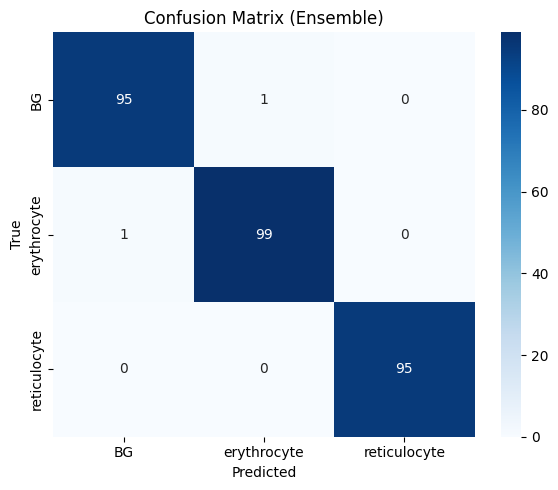


[ENSEMBLED SUMMARY] Acc=99.31, F1=99.32


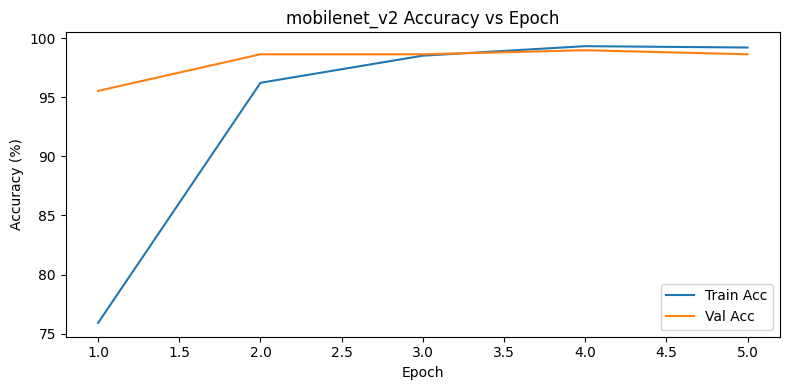

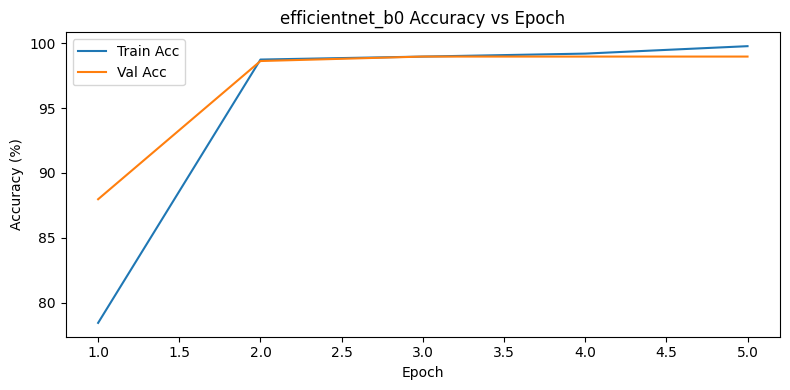

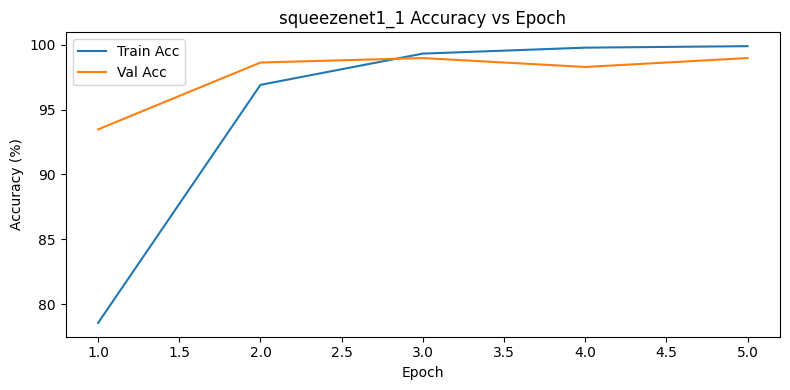

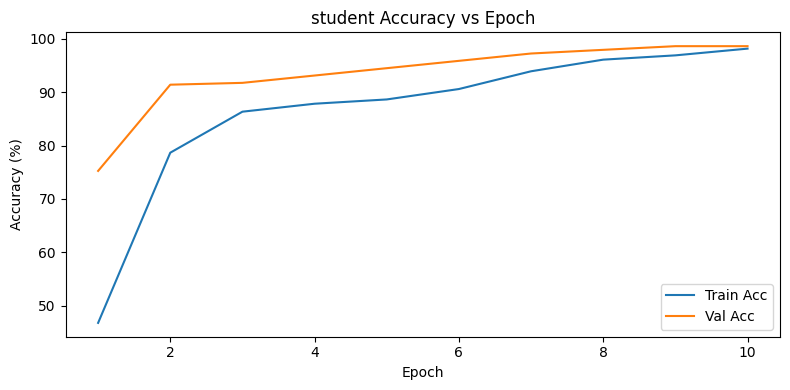

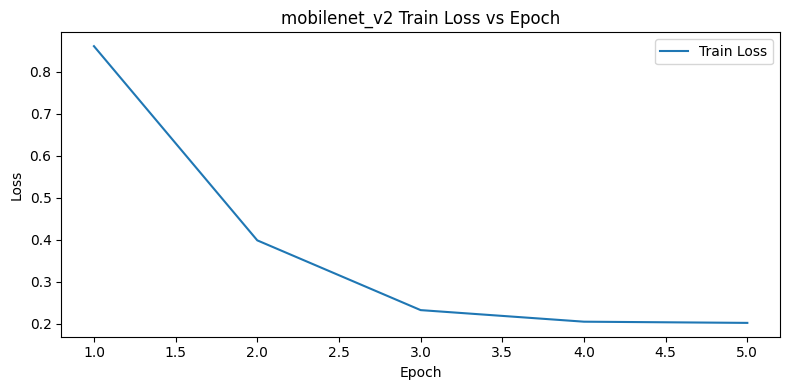

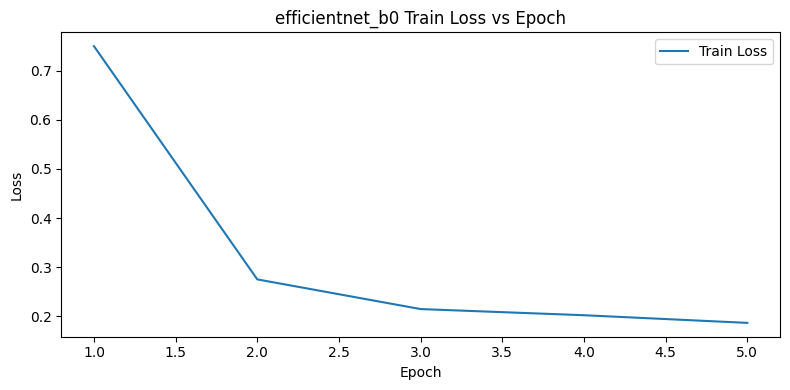

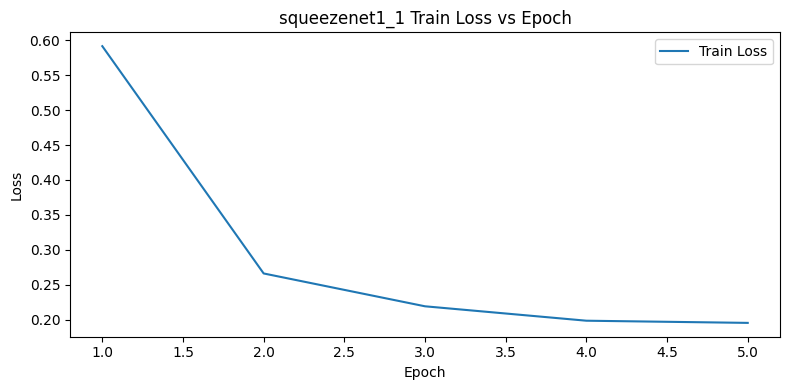

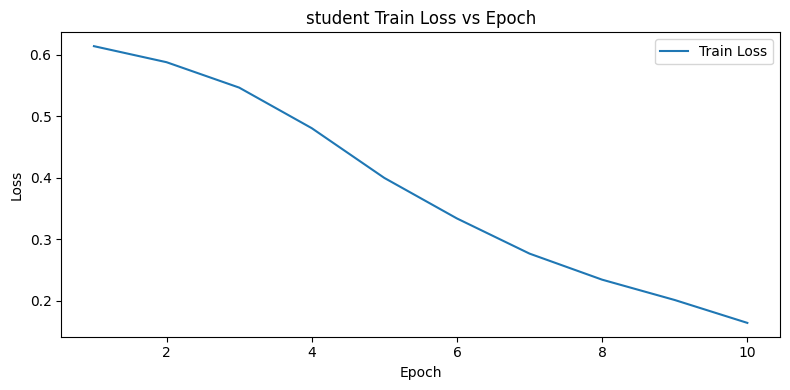

In [7]:
# ====================== Confusion matrix (inline plot) ======================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=human_base.classes,
            yticklabels=human_base.classes)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix (Ensemble)")
plt.tight_layout()
plt.show()   # 👈 display on interface instead of saving

# ====================== Ensemble summary stats ======================
acc = accuracy_score(y_true, y_pred)*100.0
f1m = f1_score(y_true, y_pred, average="macro")*100.0
print(f"\n[ENSEMBLED SUMMARY] Acc={acc:.2f}, F1={f1m:.2f}")

# ====================== Extra Plots (inline display) ======================
# Accuracy vs Epoch
for name, logs in history.items():
    plt.figure(figsize=(8,4))
    plt.plot(logs["epoch"], logs["train_acc"], label="Train Acc")
    plt.plot(logs["epoch"], logs["val_acc"], label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
    plt.title(f"{name} Accuracy vs Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()   # 👈 show inline

# Train Loss vs Epoch
for name, logs in history.items():
    plt.figure(figsize=(8,4))
    plt.plot(logs["epoch"], logs["train_loss"], label="Train Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{name} Train Loss vs Epoch")
    plt.legend()
    plt.tight_layout()
    plt.show()   # 👈 show inline


In [2]:


# ====================== Final Reports ======================
def final_reports(name, model, loader):
    acc, f1, y_true, y_pred = eval_metrics(model, loader, return_preds=True)
    print(f"\n[{name}] Classification Report:\n", 
          classification_report(y_true, y_pred, target_names=human_base.classes))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=human_base.classes,
                yticklabels=human_base.classes)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Confusion Matrix ({name})")
    plt.tight_layout()
    plt.savefig(SAVE_ROOT / f"{name}_confusion_matrix.png")  # save
    plt.show()  # 👈 show inline too
 


In [5]:
import os
import shutil
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

# ---------------- CONFIG ----------------
DATA_PATH = "/kaggle/input/human-reticulocyte/SubsetAlldata"
OUT_PATH  = "dataset_split"   # new folder to save splits
VAL_FRAC, TEST_FRAC = 0.2, 0.25   # 20% validation, 20% test, 60% train
SEED = 42

np.random.seed(SEED)

# ---------------- SPLIT ----------------
class_names = sorted([d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))])

for cls in class_names:
    cls_dir = os.path.join(DATA_PATH, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.png','.jpeg'))]

    # stratified split -> first train+temp, then val+test
    train_files, temp_files = train_test_split(files, test_size=(VAL_FRAC+TEST_FRAC), random_state=SEED)
    val_files, test_files   = train_test_split(temp_files, test_size=TEST_FRAC/(VAL_FRAC+TEST_FRAC), random_state=SEED)

    # copy into new folders
    for split, split_files in zip(["train","val","test"], [train_files, val_files, test_files]):
        split_dir = Path(OUT_PATH) / split / cls
        split_dir.mkdir(parents=True, exist_ok=True)
        for f in split_files:
            src = os.path.join(cls_dir, f)
            dst = split_dir / f
            shutil.copy(src, dst)

print("✅ Dataset split completed!")
print(f"Saved in: {OUT_PATH}/train, {OUT_PATH}/val, {OUT_PATH}/test")

✅ Dataset split completed!
Saved in: dataset_split/train, dataset_split/val, dataset_split/test


# 4 teacher without augmetation Teachers: MobileNetV3-Small, ShuffleNetV2 (x0.5), SqueezeNet1_1, EfficientNet-B0

Student: MobileNetV2

In [3]:
# ====================== IMPORTS ======================
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_PATH = "/kaggle/working/dataset_split/train"
VAL_PATH   = "/kaggle/working/dataset_split/val"
TEST_PATH  = "/kaggle/working/dataset_split/test"

SAVE_ROOT = Path("outputs") / "kd_noaug"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

EPOCHS_TEACHER = 5
EPOCHS_STUDENT = 10
BATCH_SIZE   = 32
LR           = 5e-5
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 2.0
IMG_SIZE     = 224
ALPHA        = 0.5
TEMPERATURE  = 4.0

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet  = [0.229, 0.224, 0.225]

# No augmentation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

train_set = datasets.ImageFolder(TRAIN_PATH, transform=train_tf)
val_set   = datasets.ImageFolder(VAL_PATH,   transform=eval_tf)
test_set  = datasets.ImageFolder(TEST_PATH,  transform=eval_tf)
NUM_CLASSES = len(train_set.classes)

print(f"Train dataset (no aug): {len(train_set)}")
print(f"Validation dataset: {len(val_set)}")
print(f"Test dataset: {len(test_set)}")

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

train_loader = make_loader(train_set, shuffle=True)
val_loader   = make_loader(val_set)
test_loader  = make_loader(test_set)

# ====================== UTILS ======================
def replace_classifier(model, num_classes):
    if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Linear):
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif isinstance(model.classifier, nn.Sequential):
        in_f = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear): in_f = layer.in_features; break
        model.classifier[-1] = nn.Linear(in_f, num_classes)
    return model

def save_state(model, path): 
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)
    return path.stat().st_size/(1024*1024)

def count_params(model): 
    return sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6

def optim_for(params, lr): 
    return torch.optim.Adam(params, lr=lr, weight_decay=WEIGHT_DECAY)

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = loss_fn(out, y)
        if train:
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP); opt.step()
        total += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return total/max(n,1), correct/max(n,1), time.time()-start

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval(); y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())
    acc = accuracy_score(y_true,y_pred)*100; f1m = f1_score(y_true,y_pred,average="macro")*100
    if return_preds: return acc,f1m,y_true,y_pred
    return acc,f1m

# ====================== REPORTING ======================
def report_all(name, model, train_losses, val_accs, times, y_true, y_pred, out_dir):
    print(f"\n==== {name} Final Report ====")
    print("Classification Report:\n", classification_report(y_true,y_pred,target_names=train_set.classes))

    # Per-class metrics
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    print("\nPer-class metrics:")
    for i, cls in enumerate(train_set.classes):
        cls_mask = (np.array(y_true) == i)
        cls_acc = 100.0 * (np.array(y_pred)[cls_mask] == i).mean() if cls_mask.sum()>0 else 0.0
        print(f"{cls:15s} | Acc={cls_acc:.2f} | Prec={prec[i]*100:.2f} | Rec={rec[i]*100:.2f} | F1={f1[i]*100:.2f}")

    cm=confusion_matrix(y_true,y_pred,labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_set.classes,yticklabels=train_set.classes)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.savefig(out_dir/f"{name}_confusion.png"); plt.close()

    plt.figure(); plt.plot(range(1,len(train_losses)+1),train_losses,label="Train Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{name} Loss"); plt.legend()
    plt.savefig(out_dir/f"{name}_loss.png"); plt.close()

    plt.figure(); plt.plot(range(1,len(val_accs)+1),val_accs,label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.title(f"{name} Accuracy"); plt.legend()
    plt.savefig(out_dir/f"{name}_acc.png"); plt.close()

    size_mb = save_state(model,out_dir/f"{name}_final.pth")
    params_m = count_params(model)
    avg_time = np.mean(times)
    print(f"Model size: {size_mb:.2f} MB | Params: {params_m:.2f}M | Avg time/epoch: {avg_time:.2f}s")

# ====================== TRAIN TEACHERS ======================
def train_teacher(name, fn):
    out_dir = SAVE_ROOT/f"{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    model = fn(weights="DEFAULT"); model = replace_classifier(model, NUM_CLASSES).to(DEVICE)
    ce = nn.CrossEntropyLoss(label_smoothing=0.1); opt = optim_for(model.parameters(), LR)
    train_losses, val_accs, times = [], [], []
    best_acc = -1; best_path = out_dir/f"{name}_best.pth"
    for ep in range(EPOCHS_TEACHER):
        tr_loss,tr_acc,dur=run_epoch(model,train_loader,ce,opt)
        v_acc,_=eval_metrics(model,val_loader)
        train_losses.append(tr_loss); val_accs.append(v_acc); times.append(dur)
        print(f"[{name}] Ep{ep+1}/{EPOCHS_TEACHER}: val_acc={v_acc:.2f} time={dur:.2f}s")
        if v_acc>best_acc: best_acc=v_acc; save_state(model,best_path)
    model.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred=eval_metrics(model,test_loader,return_preds=True)
    report_all(name,model,train_losses,val_accs,times,y_true,y_pred,out_dir)
    print(f"TEST acc={acc:.2f} f1={f1:.2f}\n")
    return model

teachers_cfg = [
    ("resnet101",      models.resnet101),
    ("densenet201",  models.densenet201),
    ("efficientnet_b4", models.efficientnet_b4),
    ("densenet121",  models.densenet121),
]

teachers=[]
for name,fn in teachers_cfg:
    print(f"\n==== Training Teacher {name} ====")
    teachers.append(train_teacher(name,fn))

# ====================== KNOWLEDGE DISTILLATION ======================
class DistillLoss(nn.Module):
    def __init__(self, alpha=0.5, T=4.0):
        super().__init__(); self.alpha=alpha; self.T=T
        self.ce = nn.CrossEntropyLoss()
    def forward(self, student_logits, teacher_logits, labels):
        hard_loss = self.ce(student_logits, labels)
        soft_loss = F.kl_div(
            F.log_softmax(student_logits/self.T,dim=1),
            F.softmax(teacher_logits/self.T,dim=1),
            reduction="batchmean")*(self.T**2)
        return self.alpha*hard_loss+(1-self.alpha)*soft_loss

def train_student(student_name="shufflenetv2", teachers=teachers):
    out_dir = SAVE_ROOT/f"student_{student_name}"; out_dir.mkdir(parents=True, exist_ok=True)
    student = models.shufflenet_v2_x1_0(weights="DEFAULT")
    student = replace_classifier(student, NUM_CLASSES).to(DEVICE)
    opt = optim_for(student.parameters(), LR)
    kd_loss = DistillLoss(ALPHA,TEMPERATURE)

    train_losses, val_accs, times = [], [], []
    best_acc=-1; best_path=out_dir/f"{student_name}_best.pth"

    for ep in range(EPOCHS_STUDENT):
        student.train()
        total_loss,total_correct,n=0.0,0,0
        start=time.time()
        for x,y in train_loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.no_grad():
                teacher_logits=[t(x) for t in teachers]
                avg_teacher_logits=sum(teacher_logits)/len(teacher_logits)
            student_logits=student(x)
            loss=kd_loss(student_logits,avg_teacher_logits,y)
            loss.backward(); nn.utils.clip_grad_norm_(student.parameters(),GRAD_CLIP); opt.step()
            total_loss+=loss.item()*x.size(0)
            total_correct+=(student_logits.argmax(1)==y).sum().item(); n+=x.size(0)
        dur=time.time()-start
        v_acc,_=eval_metrics(student,val_loader)
        train_losses.append(total_loss/max(n,1)); val_accs.append(v_acc); times.append(dur)
        print(f"[Student] Ep{ep+1}/{EPOCHS_STUDENT}: val_acc={v_acc:.2f} time={dur:.2f}s")
        if v_acc>best_acc: best_acc=v_acc; save_state(student,best_path)

    student.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred=eval_metrics(student,test_loader,return_preds=True)
    report_all(student_name,student,train_losses,val_accs,times,y_true,y_pred,out_dir)
    print(f"[Student] TEST acc={acc:.2f} f1={f1:.2f}\n")
    return student

student = train_student()

# ====================== ENSEMBLE EVALUATION ======================
@torch.no_grad()
def eval_ensemble(name, teachers, loader=test_loader):
    y_true,y_pred=[],[]
    for x,y in loader:
        x=x.to(DEVICE)
        with torch.no_grad():
            teacher_logits=[t(x) for t in teachers]
            avg_teacher_logits=sum(teacher_logits)/len(teacher_logits)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(avg_teacher_logits.argmax(1).cpu().numpy().tolist())
    out_dir = SAVE_ROOT/f"ensemble_{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    report_all(f"Ensemble_{name}", teachers[0], [0]*EPOCHS_TEACHER, [0]*EPOCHS_TEACHER, [0]*EPOCHS_TEACHER, y_true, y_pred, out_dir)

eval_ensemble("4teachers", teachers)


Train dataset (no aug): 799
Validation dataset: 291
Test dataset: 364

==== Training Teacher resnet101 ====


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth
100%|██████████| 171M/171M [00:00<00:00, 198MB/s] 


[resnet101] Ep1/5: val_acc=92.10 time=15.99s
[resnet101] Ep2/5: val_acc=98.63 time=15.30s
[resnet101] Ep3/5: val_acc=98.97 time=16.38s
[resnet101] Ep4/5: val_acc=98.97 time=17.54s
[resnet101] Ep5/5: val_acc=98.97 time=19.56s

==== resnet101 Final Report ====
Classification Report:
               precision    recall  f1-score   support

          BG       0.98      1.00      0.99       120
 erythrocyte       0.99      0.99      0.99       125
reticulocyte       1.00      0.98      0.99       119

    accuracy                           0.99       364
   macro avg       0.99      0.99      0.99       364
weighted avg       0.99      0.99      0.99       364


Per-class metrics:
BG              | Acc=100.00 | Prec=98.36 | Rec=100.00 | F1=99.17
erythrocyte     | Acc=99.20 | Prec=99.20 | Rec=99.20 | F1=99.20
reticulocyte    | Acc=98.32 | Prec=100.00 | Rec=98.32 | F1=99.15
Model size: 162.75 MB | Params: 42.51M | Avg time/epoch: 16.95s
TEST acc=99.18 f1=99.18


==== Training Teacher densenet2

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 171MB/s] 


[densenet201_a] Ep1/5: val_acc=98.63 time=15.64s
[densenet201_a] Ep2/5: val_acc=99.66 time=14.92s
[densenet201_a] Ep3/5: val_acc=100.00 time=14.72s
[densenet201_a] Ep4/5: val_acc=99.66 time=14.88s
[densenet201_a] Ep5/5: val_acc=100.00 time=15.20s

==== densenet201_a Final Report ====
Classification Report:
               precision    recall  f1-score   support

          BG       1.00      1.00      1.00       120
 erythrocyte       1.00      1.00      1.00       125
reticulocyte       1.00      1.00      1.00       119

    accuracy                           1.00       364
   macro avg       1.00      1.00      1.00       364
weighted avg       1.00      1.00      1.00       364


Per-class metrics:
BG              | Acc=100.00 | Prec=100.00 | Rec=100.00 | F1=100.00
erythrocyte     | Acc=100.00 | Prec=100.00 | Rec=100.00 | F1=100.00
reticulocyte    | Acc=100.00 | Prec=100.00 | Rec=100.00 | F1=100.00
Model size: 70.36 MB | Params: 18.10M | Avg time/epoch: 15.07s
TEST acc=100.00 f1=100.

...

[efficientnet_b4] Ep1/5: val_acc=75.95 time=13.10s
[efficientnet_b4] Ep2/5: val_acc=90.03 time=12.98s
[efficientnet_b4] Ep3/5: val_acc=92.44 time=12.91s
[efficientnet_b4] Ep4/5: val_acc=93.47 time=12.94s
[efficientnet_b4] Ep5/5: val_acc=94.50 time=12.92s

==== efficientnet_b4 Final Report ====
Classification Report:
               precision    recall  f1-score   support

          BG       1.00      0.97      0.99       120
 erythrocyte       0.91      1.00      0.95       125
reticulocyte       0.99      0.92      0.95       119

    accuracy                           0.96       364
   macro avg       0.97      0.96      0.96       364
weighted avg       0.97      0.96      0.96       364


Per-class metrics:
BG              | Acc=97.50 | Prec=100.00 | Rec=97.50 | F1=98.73
erythrocyte     | Acc=100.00 | Prec=91.24 | Rec=100.00 | F1=95.42
reticulocyte    | Acc=91.60 | Prec=99.09 | Rec=91.60 | F1=95.20
Model size: 67.69 MB | Params: 17.55M | Avg time/epoch: 12.97s
TEST acc=96.43 f1=96.4

Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


Model size: 70.36 MB | Params: 18.10M | Avg time/epoch: 15.05s
TEST acc=99.73 f1=99.73



100%|██████████| 8.79M/8.79M [00:00<00:00, 83.0MB/s]


[Student] Ep1/10: val_acc=88.66 time=18.97s
[Student] Ep2/10: val_acc=90.72 time=18.97s
[Student] Ep3/10: val_acc=93.13 time=18.98s
[Student] Ep4/10: val_acc=94.85 time=18.97s
[Student] Ep5/10: val_acc=95.88 time=18.97s
[Student] Ep6/10: val_acc=94.16 time=18.97s
[Student] Ep7/10: val_acc=96.91 time=18.84s
[Student] Ep8/10: val_acc=97.59 time=18.71s
[Student] Ep9/10: val_acc=97.59 time=18.69s
[Student] Ep10/10: val_acc=98.63 time=18.82s

==== shufflenetv2 Final Report ====
Classification Report:
               precision    recall  f1-score   support

          BG       0.99      1.00      1.00       120
 erythrocyte       0.99      1.00      1.00       125
reticulocyte       1.00      0.98      0.99       119

    accuracy                           0.99       364
   macro avg       0.99      0.99      0.99       364
weighted avg       0.99      0.99      0.99       364


Per-class metrics:
BG              | Acc=100.00 | Prec=99.17 | Rec=100.00 | F1=99.59
erythrocyte     | Acc=100.00 | 

# 4 ensemble teacher with Augmentation Teachers: MobileNetV3-Small, ShuffleNetV2 (x0.5), SqueezeNet1_1, EfficientNet-B0



In [4]:
# ====================== IMPORTS ======================
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, precision_recall_fscore_support)
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

TRAIN_PATH = "/kaggle/working/dataset_split/train"
VAL_PATH   = "/kaggle/working/dataset_split/val"
TEST_PATH  = "/kaggle/working/dataset_split/test"

SAVE_ROOT = Path("outputs") / "kd_augmented"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

EPOCHS_TEACHER = 5
EPOCHS_STUDENT = 10
BATCH_SIZE   = 32
LR           = 5e-5
WEIGHT_DECAY = 1e-4
GRAD_CLIP    = 2.0
IMG_SIZE     = 224
ALPHA        = 0.5
TEMPERATURE  = 4.0

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(40),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2),
    transforms.RandomAffine(degrees=20, translate=(0.2,0.2), scale=(0.8,1.2), shear=15),
    transforms.GaussianBlur(3, sigma=(0.1,2.0)),
    transforms.ToTensor(),
    transforms.RandomApply([transforms.RandomErasing(p=1.0, scale=(0.02,0.15))], p=0.5),
    transforms.Normalize(mean_imnet, std_imnet),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

train_set = datasets.ImageFolder(TRAIN_PATH, transform=train_tf)
val_set   = datasets.ImageFolder(VAL_PATH,   transform=eval_tf)
test_set  = datasets.ImageFolder(TEST_PATH,  transform=eval_tf)
NUM_CLASSES = len(train_set.classes)

print(f"Train dataset (augmented): {len(train_set)}")
print(f"Validation dataset: {len(val_set)}")
print(f"Test dataset: {len(test_set)}")

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

train_loader = make_loader(train_set, shuffle=True)
val_loader   = make_loader(val_set)
test_loader  = make_loader(test_set)

# ====================== UTILS ======================
def replace_classifier(model, num_classes):
    if hasattr(model, 'fc') and isinstance(model.fc, nn.Linear):
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Linear):
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif isinstance(model.classifier, nn.Sequential):
        in_f = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear): in_f = layer.in_features; break
        model.classifier[-1] = nn.Linear(in_f, num_classes)
    return model

def save_state(model, path): 
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)
    return path.stat().st_size/(1024*1024)

def count_params(model): 
    return sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6

def optim_for(params, lr): 
    return torch.optim.Adam(params, lr=lr, weight_decay=WEIGHT_DECAY)

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = loss_fn(out, y)
        if train:
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP); opt.step()
        total += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item(); n += x.size(0)
    return total/max(n,1), correct/max(n,1), time.time()-start

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval(); y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())
    acc = accuracy_score(y_true,y_pred)*100; f1m = f1_score(y_true,y_pred,average="macro")*100
    if return_preds: return acc,f1m,y_true,y_pred
    return acc,f1m

# ====================== REPORTING ======================
def report_all(name, model, train_losses, val_accs, times, y_true, y_pred, out_dir):
    print(f"\n==== {name} Final Report ====")
    print("Classification Report:\n", classification_report(y_true,y_pred,target_names=train_set.classes))

    # Per-class metrics (accuracy, precision, recall, F1)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    print("\nPer-class metrics:")
    for i, cls in enumerate(train_set.classes):
        cls_mask = (np.array(y_true) == i)
        cls_acc = 100.0 * (np.array(y_pred)[cls_mask] == i).mean() if cls_mask.sum()>0 else 0.0
        print(f"{cls:15s} | Acc={cls_acc:.2f} | Prec={prec[i]*100:.2f} | Rec={rec[i]*100:.2f} | F1={f1[i]*100:.2f}")

    cm=confusion_matrix(y_true,y_pred,labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_set.classes,yticklabels=train_set.classes)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.savefig(out_dir/f"{name}_confusion.png"); plt.close()

    plt.figure(); plt.plot(range(1,len(train_losses)+1),train_losses,label="Train Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{name} Loss"); plt.legend()
    plt.savefig(out_dir/f"{name}_loss.png"); plt.close()

    plt.figure(); plt.plot(range(1,len(val_accs)+1),val_accs,label="Val Acc")
    plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.title(f"{name} Accuracy"); plt.legend()
    plt.savefig(out_dir/f"{name}_acc.png"); plt.close()

    size_mb = save_state(model,out_dir/f"{name}_final.pth")
    params_m = count_params(model)
    avg_time = np.mean(times)
    print(f"Model size: {size_mb:.2f} MB | Params: {params_m:.2f}M | Avg time/epoch: {avg_time:.2f}s")

# ====================== TRAIN TEACHERS ======================
def train_teacher(name, fn):
    out_dir = SAVE_ROOT/f"{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    model = fn(weights="DEFAULT"); model = replace_classifier(model, NUM_CLASSES).to(DEVICE)
    ce = nn.CrossEntropyLoss(label_smoothing=0.1); opt = optim_for(model.parameters(), LR)
    train_losses, val_accs, times = [], [], []
    best_acc = -1; best_path = out_dir/f"{name}_best.pth"
    for ep in range(EPOCHS_TEACHER):
        tr_loss,tr_acc,dur=run_epoch(model,train_loader,ce,opt)
        v_acc,_=eval_metrics(model,val_loader)
        train_losses.append(tr_loss); val_accs.append(v_acc); times.append(dur)
        print(f"[{name}] Ep{ep+1}/{EPOCHS_TEACHER}: val_acc={v_acc:.2f} time={dur:.2f}s")
        if v_acc>best_acc: best_acc=v_acc; save_state(model,best_path)
    model.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred=eval_metrics(model,test_loader,return_preds=True)
    report_all(name,model,train_losses,val_accs,times,y_true,y_pred,out_dir)
    print(f"TEST acc={acc:.2f} f1={f1:.2f}\n")
    return model

teachers_cfg = [
    ("resnet101",      models.resnet101),
    ("densenet201_a",  models.densenet201),
    ("efficientnet_b4", models.efficientnet_b4),
    ("densenet121",  models.densenet121),
]

teachers=[]
for name,fn in teachers_cfg:
    print(f"\n==== Training Teacher {name} ====")
    teachers.append(train_teacher(name,fn))

# ====================== KNOWLEDGE DISTILLATION ======================
class DistillLoss(nn.Module):
    def __init__(self, alpha=0.5, T=4.0):
        super().__init__(); self.alpha=alpha; self.T=T
        self.ce = nn.CrossEntropyLoss()
    def forward(self, student_logits, teacher_logits, labels):
        hard_loss = self.ce(student_logits, labels)
        soft_loss = F.kl_div(
            F.log_softmax(student_logits/self.T,dim=1),
            F.softmax(teacher_logits/self.T,dim=1),
            reduction="batchmean")*(self.T**2)
        return self.alpha*hard_loss+(1-self.alpha)*soft_loss

def train_student(student_name="shufflenetv2", teachers=teachers):
    out_dir = SAVE_ROOT/f"student_{student_name}"; out_dir.mkdir(parents=True, exist_ok=True)
    student = models.shufflenet_v2_x1_0(weights="DEFAULT")
    student = replace_classifier(student, NUM_CLASSES).to(DEVICE)
    opt = optim_for(student.parameters(), LR)
    kd_loss = DistillLoss(ALPHA,TEMPERATURE)

    train_losses, val_accs, times = [], [], []
    best_acc=-1; best_path=out_dir/f"{student_name}_best.pth"

    for ep in range(EPOCHS_STUDENT):
        student.train()
        total_loss,total_correct,n=0.0,0,0
        start=time.time()
        for x,y in train_loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.no_grad():
                teacher_logits=[t(x) for t in teachers]
                avg_teacher_logits=sum(teacher_logits)/len(teacher_logits)
            student_logits=student(x)
            loss=kd_loss(student_logits,avg_teacher_logits,y)
            loss.backward(); nn.utils.clip_grad_norm_(student.parameters(),GRAD_CLIP); opt.step()
            total_loss+=loss.item()*x.size(0)
            total_correct+=(student_logits.argmax(1)==y).sum().item(); n+=x.size(0)
        dur=time.time()-start
        v_acc,_=eval_metrics(student,val_loader)
        train_losses.append(total_loss/max(n,1)); val_accs.append(v_acc); times.append(dur)
        print(f"[Student] Ep{ep+1}/{EPOCHS_STUDENT}: val_acc={v_acc:.2f} time={dur:.2f}s")
        if v_acc>best_acc: best_acc=v_acc; save_state(student,best_path)

    student.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred=eval_metrics(student,test_loader,return_preds=True)
    report_all(student_name,student,train_losses,val_accs,times,y_true,y_pred,out_dir)
    print(f"[Student] TEST acc={acc:.2f} f1={f1:.2f}\n")
    return student

student = train_student()

# ====================== ENSEMBLE EVALUATION ======================
@torch.no_grad()
def eval_ensemble(name, teachers, loader=test_loader):
    y_true,y_pred=[],[]
    for x,y in loader:
        x=x.to(DEVICE)
        with torch.no_grad():
            teacher_logits=[t(x) for t in teachers]
            avg_teacher_logits=sum(teacher_logits)/len(teacher_logits)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(avg_teacher_logits.argmax(1).cpu().numpy().tolist())
    out_dir = SAVE_ROOT/f"ensemble_{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    report_all(f"Ensemble_{name}", teachers[0], [0]*EPOCHS_TEACHER, [0]*EPOCHS_TEACHER, [0]*EPOCHS_TEACHER, y_true, y_pred, out_dir)

eval_ensemble("4teachers", teachers)



Train dataset (augmented): 799
Validation dataset: 291
Test dataset: 364

==== Training Teacher resnet101 ====


Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth
100%|██████████| 171M/171M [00:00<00:00, 188MB/s] 


[resnet101] Ep1/5: val_acc=86.25 time=15.76s
[resnet101] Ep2/5: val_acc=89.69 time=14.03s
[resnet101] Ep3/5: val_acc=96.22 time=14.27s
[resnet101] Ep4/5: val_acc=97.25 time=14.37s
[resnet101] Ep5/5: val_acc=97.94 time=14.59s

==== resnet101 Final Report ====
Classification Report:
               precision    recall  f1-score   support

          BG       1.00      0.98      0.99       120
 erythrocyte       0.99      0.98      0.98       125
reticulocyte       0.97      1.00      0.98       119

    accuracy                           0.99       364
   macro avg       0.99      0.99      0.99       364
weighted avg       0.99      0.99      0.99       364


Per-class metrics:
BG              | Acc=98.33 | Prec=100.00 | Rec=98.33 | F1=99.16
erythrocyte     | Acc=97.60 | Prec=99.19 | Rec=97.60 | F1=98.39
reticulocyte    | Acc=100.00 | Prec=96.75 | Rec=100.00 | F1=98.35
Model size: 162.75 MB | Params: 42.51M | Avg time/epoch: 14.61s
TEST acc=98.63 f1=98.63


==== Training Teacher densenet2

Downloading: "https://download.pytorch.org/models/densenet201-c1103571.pth" to /root/.cache/torch/hub/checkpoints/densenet201-c1103571.pth
100%|██████████| 77.4M/77.4M [00:00<00:00, 183MB/s]


[densenet201_a] Ep1/5: val_acc=88.32 time=13.18s
[densenet201_a] Ep2/5: val_acc=93.81 time=13.03s
[densenet201_a] Ep3/5: val_acc=96.22 time=13.14s
[densenet201_a] Ep4/5: val_acc=97.59 time=13.23s
[densenet201_a] Ep5/5: val_acc=97.25 time=13.27s

==== densenet201_a Final Report ====
Classification Report:
               precision    recall  f1-score   support

          BG       1.00      0.97      0.98       120
 erythrocyte       0.98      0.99      0.99       125
reticulocyte       0.97      0.99      0.98       119

    accuracy                           0.98       364
   macro avg       0.98      0.98      0.98       364
weighted avg       0.98      0.98      0.98       364


Per-class metrics:
BG              | Acc=96.67 | Prec=100.00 | Rec=96.67 | F1=98.31
erythrocyte     | Acc=99.20 | Prec=98.41 | Rec=99.20 | F1=98.80
reticulocyte    | Acc=99.16 | Prec=96.72 | Rec=99.16 | F1=97.93
Model size: 70.36 MB | Params: 18.10M | Avg time/epoch: 13.17s
TEST acc=98.35 f1=98.35


==== Train

...

Model size: 67.69 MB | Params: 17.55M | Avg time/epoch: 11.52s
TEST acc=84.07 f1=83.90


==== Training Teacher densenet121 ====


100%|██████████| 30.8M/30.8M [00:00<00:00, 190MB/s]


[densenet121] Ep1/5: val_acc=82.13 time=8.78s
[densenet121] Ep2/5: val_acc=90.03 time=8.71s
[densenet121] Ep3/5: val_acc=95.88 time=8.71s
[densenet121] Ep4/5: val_acc=95.88 time=8.77s
[densenet121] Ep5/5: val_acc=94.85 time=8.74s

==== densenet121 Final Report ====
Classification Report:
               precision    recall  f1-score   support

          BG       1.00      0.97      0.99       120
 erythrocyte       0.98      0.98      0.98       125
reticulocyte       0.95      0.97      0.96       119

    accuracy                           0.98       364
   macro avg       0.98      0.98      0.98       364
weighted avg       0.98      0.98      0.98       364


Per-class metrics:
BG              | Acc=97.50 | Prec=100.00 | Rec=97.50 | F1=98.73
erythrocyte     | Acc=97.60 | Prec=97.60 | Rec=97.60 | F1=97.60
reticulocyte    | Acc=97.48 | Prec=95.08 | Rec=97.48 | F1=96.27
Model size: 27.12 MB | Params: 6.96M | Avg time/epoch: 8.74s
TEST acc=97.53 f1=97.53



Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth
100%|██████████| 8.79M/8.79M [00:00<00:00, 115MB/s]


[Student] Ep1/10: val_acc=64.60 time=14.93s
[Student] Ep2/10: val_acc=74.23 time=15.04s
[Student] Ep3/10: val_acc=78.01 time=15.04s
[Student] Ep4/10: val_acc=79.73 time=15.04s
[Student] Ep5/10: val_acc=81.79 time=15.01s
[Student] Ep6/10: val_acc=83.51 time=15.09s
[Student] Ep7/10: val_acc=85.57 time=15.14s
[Student] Ep8/10: val_acc=86.25 time=15.18s
[Student] Ep9/10: val_acc=87.29 time=15.23s
[Student] Ep10/10: val_acc=86.94 time=15.16s

==== shufflenetv2 Final Report ====
Classification Report:
               precision    recall  f1-score   support

          BG       0.97      0.78      0.87       120
 erythrocyte       0.77      0.95      0.85       125
reticulocyte       0.89      0.84      0.87       119

    accuracy                           0.86       364
   macro avg       0.88      0.86      0.86       364
weighted avg       0.88      0.86      0.86       364


Per-class metrics:
BG              | Acc=78.33 | Prec=96.91 | Rec=78.33 | F1=86.64
erythrocyte     | Acc=95.20 | Pre

# 2teacher,without augment

In [16]:
# ====================== IMPORTS ======================
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# <<<==== PATHS ====>>>
TRAIN_PATH = "/kaggle/working/dataset_split/train"
VAL_PATH   = "/kaggle/working/dataset_split/val"
TEST_PATH  = "/kaggle/working/dataset_split/test"

SAVE_ROOT = Path("outputs") / "kd_2teachers_student_noaug"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# training schedule
EPOCHS_TEACHER  = 5
EPOCHS_STUDENT  = 8
BATCH_SIZE      = 32
LR_TEACHER      = 5e-5
LR_STUDENT      = 1e-4
WEIGHT_DECAY    = 1e-4
ALPHA           = 0.5
TEMPERATURE     = 4.0
GRAD_CLIP_NORM  = 2.0
IMG_SIZE        = 224

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet  = [0.229, 0.224, 0.225]

# ⚡ Simple transforms (NO augmentation)
tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

# Dataset loaders
train_set = datasets.ImageFolder(TRAIN_PATH, transform=tf)
val_set   = datasets.ImageFolder(VAL_PATH, transform=tf)
test_set  = datasets.ImageFolder(TEST_PATH, transform=tf)
NUM_CLASSES = len(train_set.classes)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)} | Classes: {train_set.classes}")

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

train_loader = make_loader(train_set, shuffle=True)
val_loader   = make_loader(val_set)
test_loader  = make_loader(test_set)

# ====================== UTILS ======================
def replace_classifier(model, num_classes):
    if hasattr(model, 'fc'):
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_f = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear):
                in_f = layer.in_features
                break
        last_idx = None
        for i in reversed(range(len(model.classifier))):
            if isinstance(model.classifier[i], nn.Linear):
                last_idx = i; break
        if last_idx is not None:
            model.classifier[last_idx] = nn.Linear(in_f, num_classes)
    return model

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = loss_fn(out,y)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
        total += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item()
        n += x.size(0)
    return total/max(n,1), correct/max(n,1), time.time()-start

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval(); y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())

    acc  = accuracy_score(y_true,y_pred)*100
    f1m  = f1_score(y_true,y_pred,average="macro")*100
    report_dict = classification_report(
        y_true,y_pred,
        target_names=train_set.classes,
        output_dict=True, zero_division=0
    )

    if return_preds:
        return acc,f1m,y_true,y_pred,report_dict
    return acc,f1m,report_dict

def print_per_class_metrics(name, y_true, y_pred):
    report = classification_report(y_true,y_pred,target_names=train_set.classes,output_dict=True,zero_division=0)
    acc = accuracy_score(y_true,y_pred)*100
    print(f"\n==== {name} Per-Class Metrics ====")
    print(f"Overall Accuracy: {acc:.2f}%\n")
    for cls in train_set.classes:
        cls_report = report[cls]
        print(f"{cls:15s} | Prec: {cls_report['precision']*100:.2f} | "
              f"Rec: {cls_report['recall']*100:.2f} | "
              f"F1: {cls_report['f1-score']*100:.2f}")

# ====================== TEACHER TRAINING ======================
def train_teacher(name, fn):
    out_dir = SAVE_ROOT/f"{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    model = fn(weights="DEFAULT")
    model = replace_classifier(model, NUM_CLASSES).to(DEVICE)
    ce = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=LR_TEACHER, weight_decay=WEIGHT_DECAY)
    best_acc=-1; best_path=out_dir/f"{name}_best.pth"
    for ep in range(EPOCHS_TEACHER):
        tr_loss,tr_acc,dur=run_epoch(model,train_loader,ce,opt)
        v_acc,v_f1,_=eval_metrics(model,val_loader)
        print(f"[{name}] ep{ep+1}/{EPOCHS_TEACHER} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if v_acc>best_acc:
            best_acc=v_acc
            torch.save(model.state_dict(),best_path)
    model.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred,report_dict=eval_metrics(model,test_loader,return_preds=True)
    print_per_class_metrics(name,y_true,y_pred)
    return model

teachers_cfg = [
    ("mobilenet_v2", models.mobilenet_v2),
    ("efficientnet_b0", models.efficientnet_b0),
]

teachers=[]
for name,fn in teachers_cfg:
    teachers.append(train_teacher(name,fn))

# ====================== ENSEMBLE EVAL ======================
@torch.no_grad()
def eval_ensemble(teachers, loader, name="Ensemble"):
    y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        logits=[t(x) for t in teachers]
        avg_logits=sum(logits)/len(logits)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(avg_logits.argmax(1).cpu().numpy().tolist())
    print_per_class_metrics(name,y_true,y_pred)
    return y_true,y_pred

y_true_e,y_pred_e = eval_ensemble(teachers,test_loader)

# ====================== STUDENT KD ======================
class DistillLoss(nn.Module):
    def __init__(self, alpha=0.5, T=4.0):
        super().__init__()
        self.alpha=alpha; self.T=T
        self.ce = nn.CrossEntropyLoss()
    def forward(self, s_logits, t_logits, labels):
        hard = self.ce(s_logits, labels)
        soft = F.kl_div(
            F.log_softmax(s_logits/self.T,dim=1),
            F.softmax(t_logits/self.T,dim=1),
            reduction="batchmean")*(self.T**2)
        return self.alpha*hard+(1-self.alpha)*soft

def train_student(student_name="shufflenetv2", teachers=teachers):
    out_dir = SAVE_ROOT/f"student_{student_name}"; out_dir.mkdir(parents=True, exist_ok=True)
    student = models.shufflenet_v2_x1_0(weights="DEFAULT")
    student = replace_classifier(student, NUM_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(student.parameters(), lr=LR_STUDENT, weight_decay=WEIGHT_DECAY)
    kd_loss = DistillLoss(ALPHA,TEMPERATURE)

    best_acc=-1; best_path=out_dir/f"{student_name}_best.pth"
    for ep in range(EPOCHS_STUDENT):
        student.train(); total_loss,n=0.0,0; start=time.time()
        for x,y in train_loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.no_grad():
                t_logits=[t(x) for t in teachers]
                avg_t=sum(t_logits)/len(t_logits)
            s_logits=student(x)
            loss=kd_loss(s_logits,avg_t,y)
            loss.backward()
            nn.utils.clip_grad_norm_(student.parameters(),GRAD_CLIP_NORM)
            opt.step()
            total_loss+=loss.item()*x.size(0); n+=x.size(0)
        v_acc,v_f1,_=eval_metrics(student,val_loader)
        print(f"[Student] ep{ep+1}/{EPOCHS_STUDENT} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if v_acc>best_acc:
            best_acc=v_acc
            torch.save(student.state_dict(),best_path)

    student.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred,report_dict=eval_metrics(student,test_loader,return_preds=True)
    print_per_class_metrics("Student",y_true,y_pred)
    return student

student = train_student()


Train: 799 | Val: 291 | Test: 364 | Classes: ['BG', 'erythrocyte', 'reticulocyte']
[mobilenet_v2] ep1/5 val_acc=83.85 f1=83.85
[mobilenet_v2] ep2/5 val_acc=93.47 f1=93.55
[mobilenet_v2] ep3/5 val_acc=97.94 f1=97.93
[mobilenet_v2] ep4/5 val_acc=98.63 f1=98.61
[mobilenet_v2] ep5/5 val_acc=99.31 f1=99.30

==== mobilenet_v2 Per-Class Metrics ====
Overall Accuracy: 99.18%

BG              | Prec: 98.36 | Rec: 100.00 | F1: 99.17
erythrocyte     | Prec: 99.21 | Rec: 100.00 | F1: 99.60
reticulocyte    | Prec: 100.00 | Rec: 97.48 | F1: 98.72
[efficientnet_b0] ep1/5 val_acc=72.85 f1=72.04
[efficientnet_b0] ep2/5 val_acc=98.63 f1=98.62
[efficientnet_b0] ep3/5 val_acc=99.66 f1=99.66
[efficientnet_b0] ep4/5 val_acc=98.97 f1=98.98
[efficientnet_b0] ep5/5 val_acc=99.66 f1=99.65

==== efficientnet_b0 Per-Class Metrics ====
Overall Accuracy: 99.18%

BG              | Prec: 99.17 | Rec: 99.17 | F1: 99.17
erythrocyte     | Prec: 98.43 | Rec: 100.00 | F1: 99.21
reticulocyte    | Prec: 100.00 | Rec: 98.32 

# 2Teacher  with AUGMENT

In [15]:
# ====================== IMPORTS ======================
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# <<<==== PATHS ====>>>
TRAIN_PATH = "/kaggle/working/dataset_split/train"
VAL_PATH   = "/kaggle/working/dataset_split/val"
TEST_PATH  = "/kaggle/working/dataset_split/test"

SAVE_ROOT = Path("outputs") / "kd_2teachers_student_aug"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# training schedule
EPOCHS_TEACHER  = 5
EPOCHS_STUDENT  = 10
BATCH_SIZE      = 32
LR_TEACHER      = 5e-5
LR_STUDENT      = 1e-4
WEIGHT_DECAY    = 1e-4
ALPHA           = 0.5
TEMPERATURE     = 4.0
GRAD_CLIP_NORM  = 2.0
IMG_SIZE        = 224

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet  = [0.229, 0.224, 0.225]

# 🚀 Augmentation for train
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(40),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2),
    transforms.RandomAffine(degrees=20, translate=(0.2,0.2), scale=(0.8,1.2), shear=15),
    transforms.GaussianBlur(3, sigma=(0.1,2.0)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02,0.15)),
    transforms.Normalize(mean_imnet, std_imnet),
])

# Deterministic eval transforms
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

# Datasets
train_set = datasets.ImageFolder(TRAIN_PATH, transform=train_tf)
val_set   = datasets.ImageFolder(VAL_PATH,   transform=eval_tf)
test_set  = datasets.ImageFolder(TEST_PATH,  transform=eval_tf)
NUM_CLASSES = len(train_set.classes)

print(f"Train={len(train_set)} | Val={len(val_set)} | Test={len(test_set)} | Classes={train_set.classes}")

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

train_loader = make_loader(train_set, shuffle=True)
val_loader   = make_loader(val_set)
test_loader  = make_loader(test_set)

# ====================== UTILS ======================
def replace_classifier(model, num_classes):
    if hasattr(model, 'fc'):
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_f = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear): in_f = layer.in_features; break
        model.classifier[-1] = nn.Linear(in_f, num_classes)
    return model

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = loss_fn(out,y)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
        total += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item()
        n += x.size(0)
    return total/max(n,1), correct/max(n,1), time.time()-start

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval(); y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())

    acc  = accuracy_score(y_true,y_pred)*100
    f1m  = f1_score(y_true,y_pred,average="macro")*100
    prec = precision_score(y_true,y_pred,average="macro",zero_division=0)*100
    rec  = recall_score(y_true,y_pred,average="macro",zero_division=0)*100
    report_dict = classification_report(
        y_true,y_pred,
        target_names=train_set.classes,
        output_dict=True, zero_division=0
    )

    if return_preds:
        return acc,f1m,prec,rec,y_true,y_pred,report_dict
    return acc,f1m,prec,rec,report_dict

def print_reticulocyte_metrics(name, y_true, y_pred):
    report = classification_report(y_true,y_pred,target_names=train_set.classes,output_dict=True,zero_division=0)
    rec = report["reticulocyte"]
    acc = accuracy_score(y_true,y_pred)*100
    print(f"\n==== {name} (Reticulocyte only) ====")
    print(f"Accuracy:  {acc:.2f}%")
    print(f"Precision: {rec['precision']*100:.2f}%")
    print(f"Recall:    {rec['recall']*100:.2f}%")
    print(f"F1 Score:  {rec['f1-score']*100:.2f}%")

# ====================== TEACHER TRAINING ======================
def train_teacher(name, fn):
    out_dir = SAVE_ROOT/f"{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    model = fn(weights="DEFAULT")
    model = replace_classifier(model, NUM_CLASSES).to(DEVICE)
    ce = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=LR_TEACHER, weight_decay=WEIGHT_DECAY)
    best_acc=-1; best_path=out_dir/f"{name}_best.pth"
    for ep in range(EPOCHS_TEACHER):
        tr_loss,tr_acc,dur=run_epoch(model,train_loader,ce,opt)
        v_acc,v_f1,v_prec,v_rec,_=eval_metrics(model,val_loader)
        print(f"[{name}] ep{ep+1}/{EPOCHS_TEACHER} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if v_acc>best_acc: best_acc=v_acc; torch.save(model.state_dict(),best_path)
    model.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,prec,rec,y_true,y_pred,report_dict=eval_metrics(model,test_loader,return_preds=True)
    print_reticulocyte_metrics(name,y_true,y_pred)
    return model

teachers_cfg = [
    ("mobilenet_v2", models.mobilenet_v2),
    ("efficientnet_b0", models.efficientnet_b0),
]

teachers=[]
for name,fn in teachers_cfg:
    teachers.append(train_teacher(name,fn))

# ====================== ENSEMBLE EVAL ======================
@torch.no_grad()
def eval_ensemble(teachers, loader, name="Ensemble"):
    y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        logits=[t(x) for t in teachers]
        avg_logits=sum(logits)/len(logits)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(avg_logits.argmax(1).cpu().numpy().tolist())
    print_reticulocyte_metrics(name,y_true,y_pred)
    return y_true,y_pred

y_true_e,y_pred_e = eval_ensemble(teachers,test_loader)

# ====================== STUDENT KD ======================
class DistillLoss(nn.Module):
    def __init__(self, alpha=0.5, T=4.0):
        super().__init__()
        self.alpha=alpha; self.T=T
        self.ce = nn.CrossEntropyLoss()
    def forward(self, s_logits, t_logits, labels):
        hard = self.ce(s_logits, labels)
        soft = F.kl_div(
            F.log_softmax(s_logits/self.T,dim=1),
            F.softmax(t_logits/self.T,dim=1),
            reduction="batchmean")*(self.T**2)
        return self.alpha*hard+(1-self.alpha)*soft

def train_student(student_name="shufflenetv2", teachers=teachers):
    out_dir = SAVE_ROOT/f"student_{student_name}"; out_dir.mkdir(parents=True, exist_ok=True)
    student = models.shufflenet_v2_x1_0(weights="DEFAULT")
    student = replace_classifier(student, NUM_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(student.parameters(), lr=LR_STUDENT, weight_decay=WEIGHT_DECAY)
    kd_loss = DistillLoss(ALPHA,TEMPERATURE)

    best_acc=-1; best_path=out_dir/f"{student_name}_best.pth"
    for ep in range(EPOCHS_STUDENT):
        student.train(); total_loss,n=0.0,0; start=time.time()
        for x,y in train_loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.no_grad():
                t_logits=[t(x) for t in teachers]
                avg_t=sum(t_logits)/len(t_logits)
            s_logits=student(x)
            loss=kd_loss(s_logits,avg_t,y)
            loss.backward(); nn.utils.clip_grad_norm_(student.parameters(),GRAD_CLIP_NORM); opt.step()
            total_loss+=loss.item()*x.size(0); n+=x.size(0)
        v_acc,v_f1,v_prec,v_rec,_=eval_metrics(student,val_loader)
        print(f"[Student] ep{ep+1}/{EPOCHS_STUDENT} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if v_acc>best_acc: best_acc=v_acc; torch.save(student.state_dict(),best_path)

    student.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,prec,rec,y_true,y_pred,report_dict=eval_metrics(student,test_loader,return_preds=True)
    print_reticulocyte_metrics("Student",y_true,y_pred)
    return student

student=train_student()


Train=799 | Val=291 | Test=364 | Classes=['BG', 'erythrocyte', 'reticulocyte']
[mobilenet_v2] ep1/5 val_acc=49.83 f1=47.29
[mobilenet_v2] ep2/5 val_acc=64.26 f1=63.94
[mobilenet_v2] ep3/5 val_acc=71.48 f1=71.26
[mobilenet_v2] ep4/5 val_acc=80.76 f1=80.47
[mobilenet_v2] ep5/5 val_acc=84.19 f1=84.23


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth



==== mobilenet_v2 (Reticulocyte only) ====
Accuracy:  85.44%
Precision: 87.83%
Recall:    84.87%
F1 Score:  86.32%


100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s] 


[efficientnet_b0] ep1/5 val_acc=53.95 f1=49.68
[efficientnet_b0] ep2/5 val_acc=63.92 f1=61.79
[efficientnet_b0] ep3/5 val_acc=75.95 f1=75.31
[efficientnet_b0] ep4/5 val_acc=83.51 f1=83.41
[efficientnet_b0] ep5/5 val_acc=89.00 f1=89.04

==== efficientnet_b0 (Reticulocyte only) ====
Accuracy:  89.01%
Precision: 83.46%
Recall:    93.28%
F1 Score:  88.10%


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth



==== Ensemble (Reticulocyte only) ====
Accuracy:  89.56%
Precision: 90.08%
Recall:    91.60%
F1 Score:  90.83%


100%|██████████| 8.79M/8.79M [00:00<00:00, 89.6MB/s]


[Student] ep1/10 val_acc=71.48 f1=70.66
[Student] ep2/10 val_acc=76.29 f1=75.98
[Student] ep3/10 val_acc=76.98 f1=76.75
[Student] ep4/10 val_acc=79.38 f1=79.50
[Student] ep5/10 val_acc=81.10 f1=81.08
[Student] ep6/10 val_acc=83.16 f1=83.30
[Student] ep7/10 val_acc=83.85 f1=83.92
[Student] ep8/10 val_acc=85.57 f1=85.60
[Student] ep9/10 val_acc=87.97 f1=87.90
[Student] ep10/10 val_acc=89.35 f1=89.31

==== Student (Reticulocyte only) ====
Accuracy:  88.74%
Precision: 86.89%
Recall:    89.08%
F1 Score:  87.97%


# 1KD without augment

In [13]:
# ====================== IMPORTS ======================
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# <<<==== PATHS ====>>>
TRAIN_PATH = "/kaggle/working/dataset_split/train"
VAL_PATH   = "/kaggle/working/dataset_split/val"
TEST_PATH  = "/kaggle/working/dataset_split/test"

SAVE_ROOT = Path("outputs") / "kd_deit_teacher_student"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# Training schedule
EPOCHS_TEACHER  = 5
EPOCHS_STUDENT  = 10
BATCH_SIZE      = 32
LR_TEACHER      = 5e-5
LR_STUDENT      = 1e-4
WEIGHT_DECAY    = 1e-4
ALPHA           = 0.5
TEMPERATURE     = 4.0
GRAD_CLIP_NORM  = 2.0
IMG_SIZE        = 224

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet  = [0.229, 0.224, 0.225]

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

train_set = datasets.ImageFolder(TRAIN_PATH, transform=tf)
val_set   = datasets.ImageFolder(VAL_PATH, transform=tf)
test_set  = datasets.ImageFolder(TEST_PATH, transform=tf)
NUM_CLASSES = len(train_set.classes)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)} | Classes: {train_set.classes}")

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

train_loader = make_loader(train_set, shuffle=True)
val_loader   = make_loader(val_set)
test_loader  = make_loader(test_set)

# ====================== UTILS ======================
def replace_classifier(model, num_classes):
    if hasattr(model, 'heads'):  # ViT/DeiT
        in_f = model.heads.head.in_features
        model.heads.head = nn.Linear(in_f, num_classes)
    elif hasattr(model, 'fc'):   # CNNs
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_f = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear): in_f = layer.in_features; break
        model.classifier[-1] = nn.Linear(in_f, num_classes)
    return model

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = loss_fn(out,y)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
        total += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item()
        n += x.size(0)
    return total/max(n,1), correct/max(n,1), time.time()-start

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval(); y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())

    acc  = accuracy_score(y_true,y_pred)*100
    f1m  = f1_score(y_true,y_pred,average="macro")*100
    report_dict = classification_report(
        y_true,y_pred,
        target_names=train_set.classes,
        output_dict=True, zero_division=0
    )

    if return_preds:
        return acc,f1m,y_true,y_pred,report_dict
    return acc,f1m,report_dict

def per_class_accuracy(y_true,y_pred,classes):
    accs={}
    cm=confusion_matrix(y_true,y_pred,labels=list(range(len(classes))))
    for i,cls in enumerate(classes):
        accs[cls]=cm[i,i]/cm[i,:].sum() if cm[i,:].sum()>0 else 0.0
    return accs

def save_state(model, path): 
    torch.save(model.state_dict(), path)
    return path.stat().st_size/(1024*1024)

def count_params(model): 
    return sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6

def report_all(name, model, train_losses, val_accs, times, y_true, y_pred, report_dict, out_dir):
    print(f"\n==== {name} Final Report ====")

    # Per-class metrics
    cls_accs = per_class_accuracy(y_true,y_pred,train_set.classes)
    print("Per-class metrics:")
    for cls in train_set.classes:
        cls_report = report_dict[cls]
        print(f"{cls:15s} | Acc: {cls_accs[cls]*100:.2f} | "
              f"Prec: {cls_report['precision']*100:.2f} | "
              f"Rec: {cls_report['recall']*100:.2f} | "
              f"F1: {cls_report['f1-score']*100:.2f}")

    # Explicit Reticulocyte Accuracy
    if "reticulocyte" in cls_accs:
        retic_acc = cls_accs["reticulocyte"]*100
        print(f"\n⚡ Reticulocyte Accuracy for {name}: {retic_acc:.2f}%")

    print("\nMacro Avg:", report_dict["macro avg"])
    print("Weighted Avg:", report_dict["weighted avg"])

    # Confusion Matrix
    cm=confusion_matrix(y_true,y_pred,labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_set.classes,yticklabels=train_set.classes)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.savefig(out_dir/f"{name}_confusion.png"); plt.close()

    # Curves
    if len(train_losses)>0:
        plt.figure(); plt.plot(range(1,len(train_losses)+1),train_losses,label="Train Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"{name} Loss"); plt.legend()
        plt.savefig(out_dir/f"{name}_loss.png"); plt.close()

    if len(val_accs)>0:
        plt.figure(); plt.plot(range(1,len(val_accs)+1),val_accs,label="Val Acc")
        plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.title(f"{name} Accuracy"); plt.legend()
        plt.savefig(out_dir/f"{name}_acc.png"); plt.close()

    # Metadata
    if model is not None:
        out_path = out_dir/f"{name}_final.pth"
        size_mb = save_state(model,out_path)
        params_m = count_params(model)
        avg_time = np.mean(times) if len(times)>0 else 0
        print(f"Model size: {size_mb:.2f} MB | Params: {params_m:.2f}M | Avg time/epoch: {avg_time:.2f}s")

# ====================== TEACHER TRAINING ======================
def train_teacher(name, fn):
    out_dir = SAVE_ROOT/f"{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    model = fn(weights="DEFAULT")
    model = replace_classifier(model, NUM_CLASSES).to(DEVICE)
    ce = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=LR_TEACHER, weight_decay=WEIGHT_DECAY)
    train_losses,val_accs,times=[],[],[]
    best_acc=-1; best_path=out_dir/f"{name}_best.pth"
    for ep in range(EPOCHS_TEACHER):
        tr_loss,tr_acc,dur=run_epoch(model,train_loader,ce,opt)
        v_acc,v_f1,_=eval_metrics(model,val_loader)
        train_losses.append(tr_loss); val_accs.append(v_acc); times.append(dur)
        print(f"[{name}] ep{ep+1}/{EPOCHS_TEACHER} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if v_acc>best_acc: best_acc=v_acc; torch.save(model.state_dict(),best_path)
    model.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred,report_dict=eval_metrics(model,test_loader,return_preds=True)
    report_all(name,model,train_losses,val_accs,times,y_true,y_pred,report_dict,out_dir)
    print(f"TEST acc={acc:.2f} f1={f1:.2f}")
    return model

teacher = train_teacher("vit_b_16", models.vit_b_16)

# ====================== ENSEMBLE EVAL ======================
@torch.no_grad()
def eval_ensemble(teachers, loader, name="Ensemble"):
    y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        logits=[t(x) for t in teachers]
        avg_logits=sum(logits)/len(logits)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(avg_logits.argmax(1).cpu().numpy().tolist())
    acc  = accuracy_score(y_true,y_pred)*100
    f1m  = f1_score(y_true,y_pred,average="macro")*100
    report_dict = classification_report(
        y_true,y_pred,
        target_names=train_set.classes,
        output_dict=True, zero_division=0
    )
    out_dir = SAVE_ROOT/f"{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    report_all(name,None,[],[],[0],y_true,y_pred,report_dict,out_dir)
    print(f"[{name}] TEST acc={acc:.2f} f1={f1m:.2f}")

# ====================== STUDENT KD ======================
class DistillLoss(nn.Module):
    def __init__(self, alpha=0.5, T=4.0):
        super().__init__()
        self.alpha=alpha; self.T=T
        self.ce = nn.CrossEntropyLoss()
    def forward(self, s_logits, t_logits, labels):
        hard = self.ce(s_logits, labels)
        soft = F.kl_div(
            F.log_softmax(s_logits/self.T,dim=1),
            F.softmax(t_logits/self.T,dim=1),
            reduction="batchmean")*(self.T**2)
        return self.alpha*hard+(1-self.alpha)*soft

def train_student(student_name="mobilenet_v3_small", teacher=teacher):
    out_dir = SAVE_ROOT/f"student_{student_name}"; out_dir.mkdir(parents=True, exist_ok=True)
    student = models.mobilenet_v3_small(weights="DEFAULT")
    student = replace_classifier(student, NUM_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(student.parameters(), lr=LR_STUDENT, weight_decay=WEIGHT_DECAY)
    kd_loss = DistillLoss(ALPHA,TEMPERATURE)

    train_losses,val_accs,times=[],[],[]
    best_acc=-1; best_path=out_dir/f"{student_name}_best.pth"

    for ep in range(EPOCHS_STUDENT):
        student.train(); total_loss, n = 0.0, 0; start = time.time()
        for x,y in train_loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.no_grad(): t_logits = teacher(x)
            s_logits = student(x)
            loss = kd_loss(s_logits, t_logits, y)
            loss.backward(); nn.utils.clip_grad_norm_(student.parameters(),GRAD_CLIP_NORM); opt.step()
            total_loss += loss.item()*x.size(0); n += x.size(0)
        dur=time.time()-start
        v_acc,v_f1,_=eval_metrics(student,val_loader)
        train_losses.append(total_loss/max(n,1)); val_accs.append(v_acc); times.append(dur)
        print(f"[Student] ep{ep+1}/{EPOCHS_STUDENT} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if v_acc>best_acc: best_acc=v_acc; torch.save(student.state_dict(),best_path)

    student.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred,report_dict=eval_metrics(student,test_loader,return_preds=True)
    report_all(student_name,student,train_losses,val_accs,times,y_true,y_pred,report_dict,out_dir)
    print(f"[Student] TEST acc={acc:.2f} f1={f1:.2f}")
    return student

student = train_student()


Train: 799 | Val: 291 | Test: 364 | Classes: ['BG', 'erythrocyte', 'reticulocyte']
[vit_b_16] ep1/5 val_acc=96.56 f1=96.53
[vit_b_16] ep2/5 val_acc=96.56 f1=96.56
[vit_b_16] ep3/5 val_acc=98.28 f1=98.30
[vit_b_16] ep4/5 val_acc=98.63 f1=98.63
[vit_b_16] ep5/5 val_acc=99.66 f1=99.66

==== vit_b_16 Final Report ====
Per-class metrics:
BG              | Acc: 100.00 | Prec: 99.17 | Rec: 100.00 | F1: 99.59
erythrocyte     | Acc: 99.20 | Prec: 100.00 | Rec: 99.20 | F1: 99.60
reticulocyte    | Acc: 99.16 | Prec: 99.16 | Rec: 99.16 | F1: 99.16

⚡ Reticulocyte Accuracy for vit_b_16: 99.16%

Macro Avg: {'precision': 0.9944440586151817, 'recall': 0.994532212885154, 'f1-score': 0.994477065601691, 'support': 364}
Weighted Avg: {'precision': 0.9945281990736535, 'recall': 0.9945054945054945, 'f1-score': 0.9945056776282093, 'support': 364}
Model size: 327.36 MB | Params: 85.80M | Avg time/epoch: 32.91s
TEST acc=99.45 f1=99.45
[Student] ep1/10 val_acc=49.83 f1=44.91
[Student] ep2/10 val_acc=55.67 f1=48

# 1KD WITH AUGMENT

In [6]:
# ====================== IMPORTS ======================
import os, time, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

# ====================== CONFIG ======================
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# <<<==== PATHS ====>>>
TRAIN_PATH = "/kaggle/working/dataset_split/train"
VAL_PATH   = "/kaggle/working/dataset_split/val"
TEST_PATH  = "/kaggle/working/dataset_split/test"

SAVE_ROOT = Path("outputs") / "kd_deit_teacher_student_noaug"
SAVE_ROOT.mkdir(parents=True, exist_ok=True)

# Training schedule
EPOCHS_TEACHER  = 5
EPOCHS_STUDENT  = 10
BATCH_SIZE      = 32
LR_TEACHER      = 5e-5
LR_STUDENT      = 1e-4
WEIGHT_DECAY    = 1e-4
ALPHA           = 0.5
TEMPERATURE     = 4.0
GRAD_CLIP_NORM  = 2.0
IMG_SIZE        = 224

# ====================== DATA ======================
mean_imnet = [0.485, 0.456, 0.406]
std_imnet  = [0.229, 0.224, 0.225]

# 🚀 Augmentation for train
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(40),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.2),
    transforms.RandomAffine(degrees=20, translate=(0.2,0.2), scale=(0.8,1.2), shear=15),
    transforms.GaussianBlur(3, sigma=(0.1,2.0)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5, scale=(0.02,0.15)),
    transforms.Normalize(mean_imnet, std_imnet),
])

# Deterministic eval transforms
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean_imnet, std_imnet),
])

train_set = datasets.ImageFolder(TRAIN_PATH, transform=train_tf)
val_set   = datasets.ImageFolder(VAL_PATH, transform=test_tf)
test_set  = datasets.ImageFolder(TEST_PATH, transform=test_tf)
NUM_CLASSES = len(train_set.classes)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)} | Classes: {train_set.classes}")

def make_loader(ds, shuffle=False):
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=2, pin_memory=True)

train_loader = make_loader(train_set, shuffle=True)
val_loader   = make_loader(val_set)
test_loader  = make_loader(test_set)

# ====================== UTILS ======================
def replace_classifier(model, num_classes):
    if hasattr(model, 'heads'):  # ViT/DeiT
        in_f = model.heads.head.in_features
        model.heads.head = nn.Linear(in_f, num_classes)
    elif hasattr(model, 'fc'):   # CNNs
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, num_classes)
    elif hasattr(model, 'classifier') and isinstance(model.classifier, nn.Sequential):
        in_f = None
        for layer in reversed(model.classifier):
            if isinstance(layer, nn.Linear): in_f = layer.in_features; break
        model.classifier[-1] = nn.Linear(in_f, num_classes)
    return model

def run_epoch(model, loader, loss_fn, opt=None):
    train = opt is not None
    model.train(train)
    total, correct, n = 0.0, 0, 0
    start = time.time()
    for x,y in loader:
        x,y = x.to(DEVICE), y.to(DEVICE)
        if train: opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = loss_fn(out,y)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            opt.step()
        total += loss.item()*x.size(0)
        correct += (out.argmax(1)==y).sum().item()
        n += x.size(0)
    return total/max(n,1), correct/max(n,1), time.time()-start

@torch.no_grad()
def eval_metrics(model, loader, return_preds=False):
    model.eval(); y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(model(x).argmax(1).cpu().numpy().tolist())

    acc  = accuracy_score(y_true,y_pred)*100
    f1m  = f1_score(y_true,y_pred,average="macro")*100
    report_dict = classification_report(
        y_true,y_pred,
        target_names=train_set.classes,
        output_dict=True, zero_division=0
    )

    if return_preds:
        return acc,f1m,y_true,y_pred,report_dict
    return acc,f1m,report_dict

def per_class_accuracy(y_true,y_pred,classes):
    accs={}
    cm=confusion_matrix(y_true,y_pred,labels=list(range(len(classes))))
    for i,cls in enumerate(classes):
        accs[cls]=cm[i,i]/cm[i,:].sum() if cm[i,:].sum()>0 else 0.0
    return accs

def save_state(model, path): 
    torch.save(model.state_dict(), path)
    return path.stat().st_size/(1024*1024)

def count_params(model): 
    return sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6

def report_all(name, model, train_losses, val_accs, times, y_true, y_pred, report_dict, out_dir):
    print(f"\n==== {name} Final Report ====")

    cls_accs = per_class_accuracy(y_true,y_pred,train_set.classes)
    for cls in train_set.classes:
        cls_report = report_dict[cls]
        print(f"{cls:15s} | Acc: {cls_accs[cls]*100:.2f} | "
              f"Prec: {cls_report['precision']*100:.2f} | "
              f"Rec: {cls_report['recall']*100:.2f} | "
              f"F1: {cls_report['f1-score']*100:.2f}")

    if "reticulocyte" in cls_accs:
        print(f"\n⚡ Reticulocyte Metrics for {name}: "
              f"Acc={cls_accs['reticulocyte']*100:.2f}% | "
              f"Prec={report_dict['reticulocyte']['precision']*100:.2f}% | "
              f"Rec={report_dict['reticulocyte']['recall']*100:.2f}% | "
              f"F1={report_dict['reticulocyte']['f1-score']*100:.2f}%")

    cm=confusion_matrix(y_true,y_pred,labels=list(range(NUM_CLASSES)))
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=train_set.classes,yticklabels=train_set.classes)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"{name} Confusion Matrix")
    plt.savefig(out_dir/f"{name}_confusion.png"); plt.close()

    if len(train_losses)>0:
        plt.figure(); plt.plot(range(1,len(train_losses)+1),train_losses,label="Train Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
        plt.savefig(out_dir/f"{name}_loss.png"); plt.close()

    if len(val_accs)>0:
        plt.figure(); plt.plot(range(1,len(val_accs)+1),val_accs,label="Val Acc")
        plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend()
        plt.savefig(out_dir/f"{name}_acc.png"); plt.close()

    if model is not None:
        out_path = out_dir/f"{name}_final.pth"
        size_mb = save_state(model,out_path)
        params_m = count_params(model)
        avg_time = np.mean(times) if len(times)>0 else 0
        print(f"Model size: {size_mb:.2f} MB | Params: {params_m:.2f}M | Avg time/epoch: {avg_time:.2f}s")

# ====================== TEACHER TRAINING ======================
def train_teacher(name, fn):
    out_dir = SAVE_ROOT/f"{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    model = fn(weights="DEFAULT")
    model = replace_classifier(model, NUM_CLASSES).to(DEVICE)
    ce = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(model.parameters(), lr=LR_TEACHER, weight_decay=WEIGHT_DECAY)
    train_losses,val_accs,times=[],[],[]
    best_acc=-1; best_path=out_dir/f"{name}_best.pth"
    for ep in range(EPOCHS_TEACHER):
        tr_loss,tr_acc,dur=run_epoch(model,train_loader,ce,opt)
        v_acc,v_f1,_=eval_metrics(model,val_loader)
        train_losses.append(tr_loss); val_accs.append(v_acc); times.append(dur)
        print(f"[{name}] ep{ep+1}/{EPOCHS_TEACHER} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if v_acc>best_acc: best_acc=v_acc; torch.save(model.state_dict(),best_path)
    model.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred,report_dict=eval_metrics(model,test_loader,return_preds=True)
    report_all(name,model,train_losses,val_accs,times,y_true,y_pred,report_dict,out_dir)
    print(f"TEST acc={acc:.2f} f1={f1:.2f}")
    return model

teacher = train_teacher("vit_b_16", models.vit_b_16)

# ====================== ENSEMBLE EVAL ======================
@torch.no_grad()
def eval_ensemble(teachers, loader, name="Ensemble"):
    y_true,y_pred=[],[]
    for x,y in loader:
        x = x.to(DEVICE)
        logits=[t(x) for t in teachers]
        avg_logits=sum(logits)/len(logits)
        y_true.extend(y.numpy().tolist())
        y_pred.extend(avg_logits.argmax(1).cpu().numpy().tolist())
    acc  = accuracy_score(y_true,y_pred)*100
    f1m  = f1_score(y_true,y_pred,average="macro")*100
    report_dict = classification_report(
        y_true,y_pred,
        target_names=train_set.classes,
        output_dict=True, zero_division=0
    )
    out_dir = SAVE_ROOT/f"{name}"; out_dir.mkdir(parents=True, exist_ok=True)
    report_all(name,None,[],[],[0],y_true,y_pred,report_dict,out_dir)
    print(f"[{name}] TEST acc={acc:.2f} f1={f1m:.2f}")

# ====================== STUDENT KD ======================
class DistillLoss(nn.Module):
    def __init__(self, alpha=0.5, T=4.0):
        super().__init__()
        self.alpha=alpha; self.T=T
        self.ce = nn.CrossEntropyLoss()
    def forward(self, s_logits, t_logits, labels):
        hard = self.ce(s_logits, labels)
        soft = F.kl_div(
            F.log_softmax(s_logits/self.T,dim=1),
            F.softmax(t_logits/self.T,dim=1),
            reduction="batchmean")*(self.T**2)
        return self.alpha*hard+(1-self.alpha)*soft

def train_student(student_name="mobilenet_v3_small", teacher=teacher):
    out_dir = SAVE_ROOT/f"student_{student_name}"; out_dir.mkdir(parents=True, exist_ok=True)
    student = models.mobilenet_v3_small(weights="DEFAULT")
    student = replace_classifier(student, NUM_CLASSES).to(DEVICE)
    opt = torch.optim.Adam(student.parameters(), lr=LR_STUDENT, weight_decay=WEIGHT_DECAY)
    kd_loss = DistillLoss(ALPHA,TEMPERATURE)

    train_losses,val_accs,times=[],[],[]
    best_acc=-1; best_path=out_dir/f"{student_name}_best.pth"

    for ep in range(EPOCHS_STUDENT):
        student.train(); total_loss, n = 0.0, 0; start = time.time()
        for x,y in train_loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad(set_to_none=True)
            with torch.no_grad(): t_logits = teacher(x)
            s_logits = student(x)
            loss = kd_loss(s_logits, t_logits, y)
            loss.backward(); nn.utils.clip_grad_norm_(student.parameters(),GRAD_CLIP_NORM); opt.step()
            total_loss += loss.item()*x.size(0); n += x.size(0)
        dur=time.time()-start
        v_acc,v_f1,_=eval_metrics(student,val_loader)
        train_losses.append(total_loss/max(n,1)); val_accs.append(v_acc); times.append(dur)
        print(f"[Student] ep{ep+1}/{EPOCHS_STUDENT} val_acc={v_acc:.2f} f1={v_f1:.2f}")
        if v_acc>best_acc: best_acc=v_acc; torch.save(student.state_dict(),best_path)

    student.load_state_dict(torch.load(best_path,map_location=DEVICE))
    acc,f1,y_true,y_pred,report_dict=eval_metrics(student,test_loader,return_preds=True)
    report_all(student_name,student,train_losses,val_accs,times,y_true,y_pred,report_dict,out_dir)
    print(f"[Student] TEST acc={acc:.2f} f1={f1:.2f}")
    return student

student = train_student()


Train: 799 | Val: 291 | Test: 364 | Classes: ['BG', 'erythrocyte', 'reticulocyte']


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:01<00:00, 207MB/s]  


[vit_b_16] ep1/5 val_acc=97.25 f1=97.26
[vit_b_16] ep2/5 val_acc=98.28 f1=98.29
[vit_b_16] ep3/5 val_acc=97.25 f1=97.25
[vit_b_16] ep4/5 val_acc=96.56 f1=96.57
[vit_b_16] ep5/5 val_acc=96.91 f1=96.90

==== vit_b_16 Final Report ====
BG              | Acc: 100.00 | Prec: 97.56 | Rec: 100.00 | F1: 98.77
erythrocyte     | Acc: 99.20 | Prec: 98.41 | Rec: 99.20 | F1: 98.80
reticulocyte    | Acc: 95.80 | Prec: 99.13 | Rec: 95.80 | F1: 97.44

⚡ Reticulocyte Metrics for vit_b_16: Acc=95.80% | Prec=99.13% | Rec=95.80% | F1=97.44%


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


Model size: 327.36 MB | Params: 85.80M | Avg time/epoch: 27.28s
TEST acc=98.35 f1=98.34


100%|██████████| 9.83M/9.83M [00:00<00:00, 92.8MB/s]


[Student] ep1/10 val_acc=47.08 f1=46.00
[Student] ep2/10 val_acc=75.26 f1=75.42
[Student] ep3/10 val_acc=77.32 f1=77.60
[Student] ep4/10 val_acc=79.73 f1=80.10
[Student] ep5/10 val_acc=85.57 f1=85.79
[Student] ep6/10 val_acc=83.51 f1=83.79
[Student] ep7/10 val_acc=87.63 f1=87.85
[Student] ep8/10 val_acc=89.69 f1=89.81
[Student] ep9/10 val_acc=90.38 f1=90.49
[Student] ep10/10 val_acc=83.85 f1=84.19

==== mobilenet_v3_small Final Report ====
BG              | Acc: 84.17 | Prec: 100.00 | Rec: 84.17 | F1: 91.40
erythrocyte     | Acc: 94.40 | Prec: 85.51 | Rec: 94.40 | F1: 89.73
reticulocyte    | Acc: 91.60 | Prec: 87.20 | Rec: 91.60 | F1: 89.34

⚡ Reticulocyte Metrics for mobilenet_v3_small: Acc=91.60% | Prec=87.20% | Rec=91.60% | F1=89.34%
Model size: 5.93 MB | Params: 1.52M | Avg time/epoch: 10.61s
[Student] TEST acc=90.11 f1=90.16
